# NBA Project  / Analysis Notebook

Loads the cleaned `master_player_season.csv` and covers:
1. General EDA
2. The project's 5 specific questions (3 descriptive + 2 hypothesis tests)

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import itertools



plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

df = pd.read_csv('../Data/clean_data/master_player_season.csv')
print(df.shape)
df.head(3)

(5853, 32)


,player_id,season_id,team_code,age,games,games_started,minutes,win_shares,ws_per_48,bpm,...,bmi,agility,height_bin,position_id,position_code,mvp_rank,mvp_share,is_mvp_candidate,is_champion,season_name
0,achiupr01,2,MIA,21,61,4,737,1.3,0.085,-4.1,...,26.693198,1.845455,Big-height (201-213cm),1,C,NaN,NaN,False,False,2020-21
1,achiupr01,2,MIA,21,61,4,737,1.3,0.085,-4.1,...,26.693198,1.845455,Big-height (201-213cm),4,PF,NaN,NaN,False,False,2020-21
2,achiupr01,3,TOR,22,73,28,1725,2.5,0.070,-2.6,...,26.693198,1.845455,Big-height (201-213cm),1,C,NaN,NaN,False,False,2021-22


## EDA

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5853 entries, 0 to 5852
Data columns (total 32 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   player_id         5853 non-null   str    
 1   season_id         5853 non-null   int64  
 2   team_code         5853 non-null   str    
 3   age               5853 non-null   int64  
 4   games             5853 non-null   int64  
 5   games_started     5853 non-null   int64  
 6   minutes           5853 non-null   int64  
 7   win_shares        5853 non-null   float64
 8   ws_per_48         5853 non-null   float64
 9   bpm               5853 non-null   float64
 10  vorp              5853 non-null   float64
 11  low_sample        5853 non-null   bool   
 12  experience        5853 non-null   int64  
 13  innate_ability    5853 non-null   float64
 14  full_name         5853 non-null   str    
 15  birth_date        5839 non-null   str    
 16  birth_place       5839 non-null   str    
 17  height

#### Categorical Features

For categorical features, we first use **bar charts** and **frequency tables** for an initial overview.
To analyze their relationship with the target variable, we rely on **contingency tables** (both counts and percentages) and supportive visualizations to detect potential patterns.

We then apply the **Chi-square test** to assess the overall significance of associations between categories and the target.
If the result shows a significant relationship, we proceed to perform post-hoc comparisons to identify **which specific categories differ** meaningfully.

In [68]:
# pastel palette - pistachio green & light pink
pastel_colors = ["#C1E1C1", "#FFD1DC"]

In [69]:
# Function to compute frequency table for a categorical column
def frequency_table(col):
    """
    Generates a frequency table for a given categorical column.

    Parameters:
    - col: pandas Series
      The categorical column for which the frequency table is computed.

    Returns:
    - pandas DataFrame
      A DataFrame containing:
      - 'Proportion': Absolute count of each category.
      - '%': Percentage of total occurrences.
    """

    value_counts = col.value_counts()  # Count occurrences of each category
    
    # Create a DataFrame with proportion and percentage values
    table = pd.DataFrame({
        'Proportion' : value_counts ,  # Count of each category
        '%' : round((value_counts / value_counts.sum()) * 100 , 2)  # Convert to percentage
    })
    
    return table

In [70]:
def contingency_table(data , col , target):
    """
    Generate a contingency table for a categorical column against the target variable.
    
    Parameters:
    - data: pandas DataFrame
      The dataset containing the categorical column and the target variable.
    - col: str
      The name of the categorical column for which the contingency table is created.
    - target: str
      The target variable to compare against.

    Returns:
    - tuple of pandas DataFrames
      The first DataFrame contains proportions, and the second DataFrame contains percentages.
      If `total=True`, an additional column with total proportions and percentages is added.
    """

    col_categories = data[col].unique()
    target_categories = data[target].unique()

    table = pd.DataFrame(index = target_categories)

    # Loop through each category in the column to compute contingency values
    for category in col_categories:
        
        columns = {'Proportion' : category,
                   '%' : category} 
        
        # Filter data for the current category and compute the frequency table
        filtered_data = data[target][data[col] == category]
        table = pd.concat([table , frequency_table(filtered_data).rename(columns = columns)] , 
                          axis = 1)


    # Split table into two separate DataFrames: one for proportions and one for percentages
    return table.iloc[: , : : 2] , table.iloc[: , 1 : :2]  # Selecting alternate columns (Proportions and Percentages)


In [71]:
def bar_chart(data, col, target, chart_type):
    counts = pd.crosstab(data[col], data[target])
    counts = counts.sort_index()

    if chart_type == "Frequency Bar Chart":
        data_sorted = data[col].value_counts().sort_index()
        sns.barplot(x=data_sorted.index, y=data_sorted.values, color="#C1E1C1")
        plt.ylabel("Count")

    elif chart_type == "Grouped Bar Chart":
        counts.plot(kind="bar", ax=plt.gca(), color=pastel_colors)
        plt.ylabel("Count")
        plt.legend(title=target)

    elif chart_type == "Normalized Stacked Bar Chart":
        norm_counts = counts.div(counts.sum(axis=1), axis=0)
        norm_counts.plot(kind="bar", stacked=True, ax=plt.gca(), color=pastel_colors)
        plt.ylabel("Proportion")
        plt.legend(title=target)

    plt.xlabel(col)
    plt.xticks(rotation=90)
    sns.despine()

In [72]:
def all_bar_plots(data, col, target):
    bar_types = ['Frequency Bar Chart',
                 'Grouped Bar Chart',
                 'Normalized Stacked Bar Chart']

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    for i in range(3):
        plt.sca(axs[i])
        bar_chart(data, col, target, bar_types[i])
        axs[i].set_title(bar_types[i], fontsize=10)

    plt.tight_layout()
    plt.savefig(col + '_bar_charts', dpi=300, bbox_inches="tight")
    plt.show()


In [73]:
def plot_tables(data, col, target):
    """
    Display frequency table and contingency tables (count & percentage)
    as clean heatmaps with annotations (no color intensity).
    """

    # --- Build tables ---
    freq = frequency_table(data[col]).sort_index()
    cont1, cont2 = contingency_table(data, col, target)
    cont1 = cont1[sorted(cont1.columns)]
    cont2 = cont2[sorted(cont2.columns)]

    # --- Layout ---
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(col, fontsize=20, fontweight="bold")
    tables = [freq, cont1.T, cont2.T]
    titles = [
        "Category Frequency",
        "Count by Category and Target",
        "Percentage by Category and Target"
    ]

    # --- Plot each as heatmap ---
    for ax, df, title in zip(axes, tables, titles):
        # choose format based on data type
        fmt = "d" if (df.map(lambda x: isinstance(x, (int, np.integer))).all().all()) else ".2f"

        sns.heatmap(df,
                    annot=True, fmt=fmt,
                    cmap=["white"],  # no actual color gradient
                    cbar=False,
                    linewidths=0.5,
                    linecolor="lightgray",
                    annot_kws={"size": 16},
                    ax=ax)
        ax.set_title(title, fontsize=14, pad=12)
        ax.set_xlabel("")
        ax.set_ylabel("")

    plt.tight_layout()
    plt.show()

In [74]:
def categorical_vs_target(data, col, target):
    plot_tables(data, col, target)
    all_bar_plots(data, col, target)

In [75]:
def compare_categorical_with_binary(data, feature_col, target_col, alpha=0.1):
    """
    Perform global and pairwise Chi-squared tests.
    - Print global result.
    - If significant, print only significant pairwise results.
    """
    contingency = pd.crosstab(data[feature_col], data[target_col])
    chi2, p_global, _, _ = stats.chi2_contingency(contingency)

    print(f"\n{feature_col}")
    print(f"[Global Test] p-value = {p_global:.4f}")

    if p_global < alpha:
        print(f"→ H0 rejected at {alpha*100:.0f}% significance level.")
        print("Significant pairwise differences (p < α):")

        categories = sorted(data[feature_col].dropna().unique())
        sig_pairs = []

        for cat1, cat2 in itertools.combinations(categories, 2):
            subset = data[data[feature_col].isin([cat1, cat2])]
            table = pd.crosstab(subset[feature_col], subset[target_col])

            if table.shape == (2, 2):
                _, p_pair, _, _ = stats.chi2_contingency(table)
                if p_pair < alpha:
                    sig_pairs.append((cat1, cat2, p_pair))

        if sig_pairs:
            for cat1, cat2, p in sig_pairs:
                print(f"  {cat1} vs {cat2} → p = {p:.4f}")
        else:
            print("  No pairwise differences found.")
    else:
        print(f" H0 NOT rejected at {alpha*100:.0f}% level. No significant difference.")

In [94]:
categorical_columns = ['position_code', 'height_bin', 'shoots', 'low_sample', 'season_name']
# target = 'is_champion'
target = 'is_mvp_candidate'

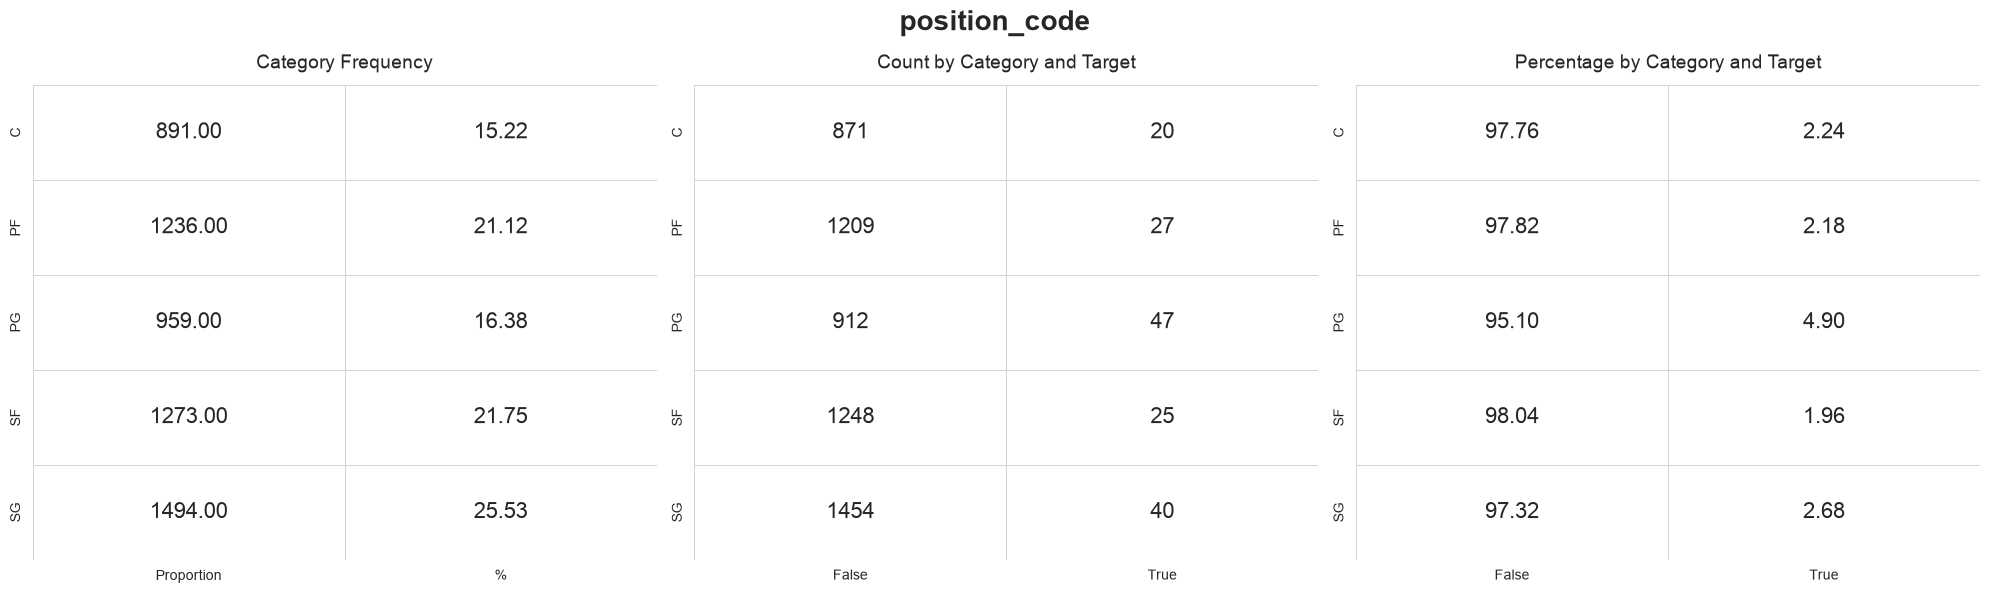

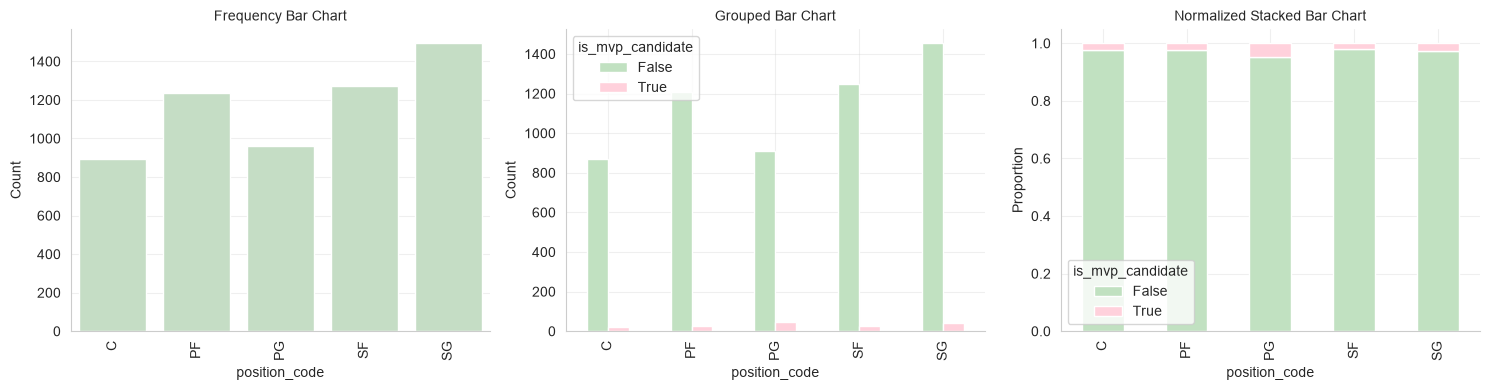

In [95]:
categorical_vs_target(df , categorical_columns[0] , target)

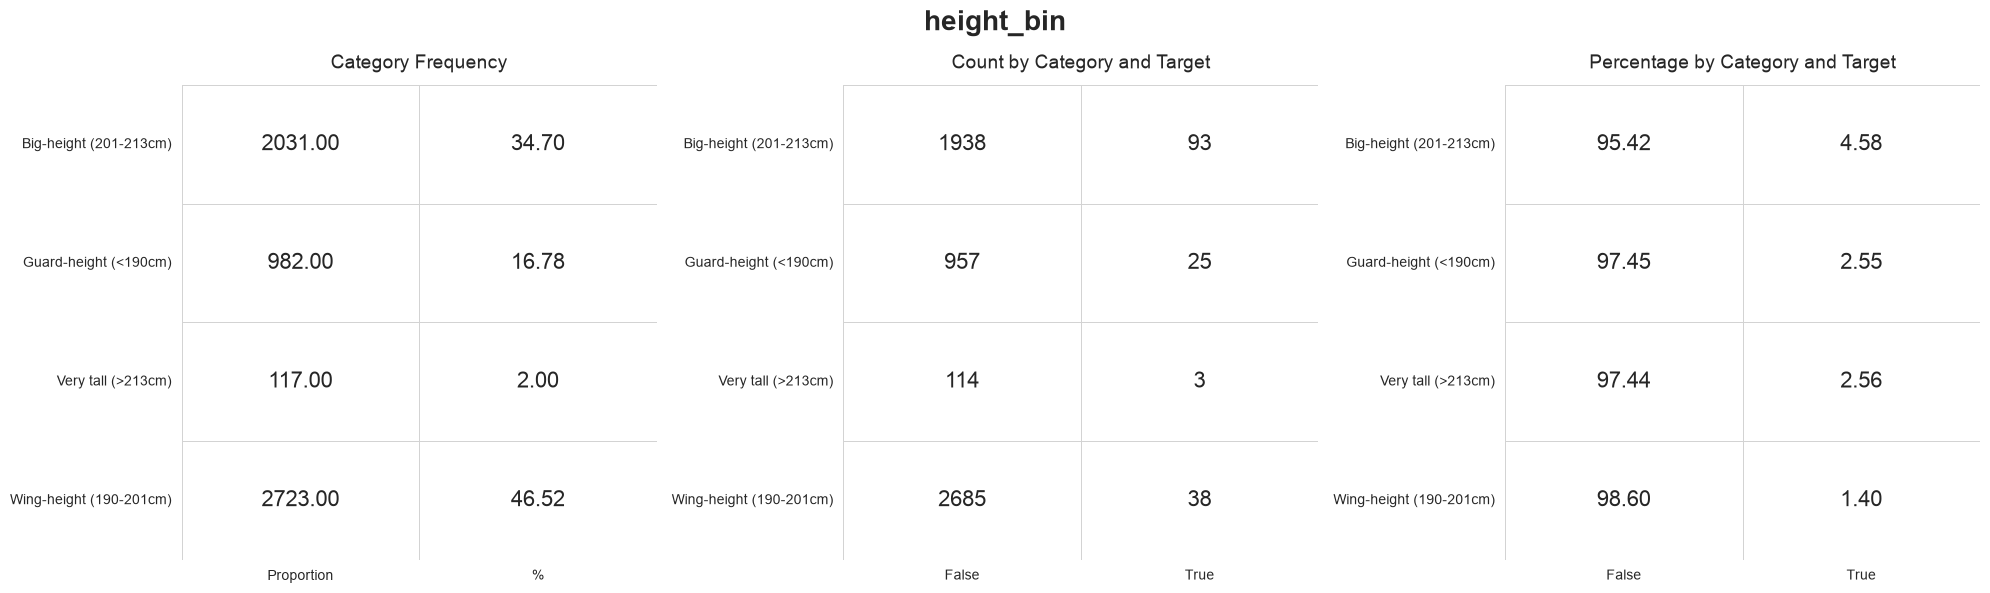

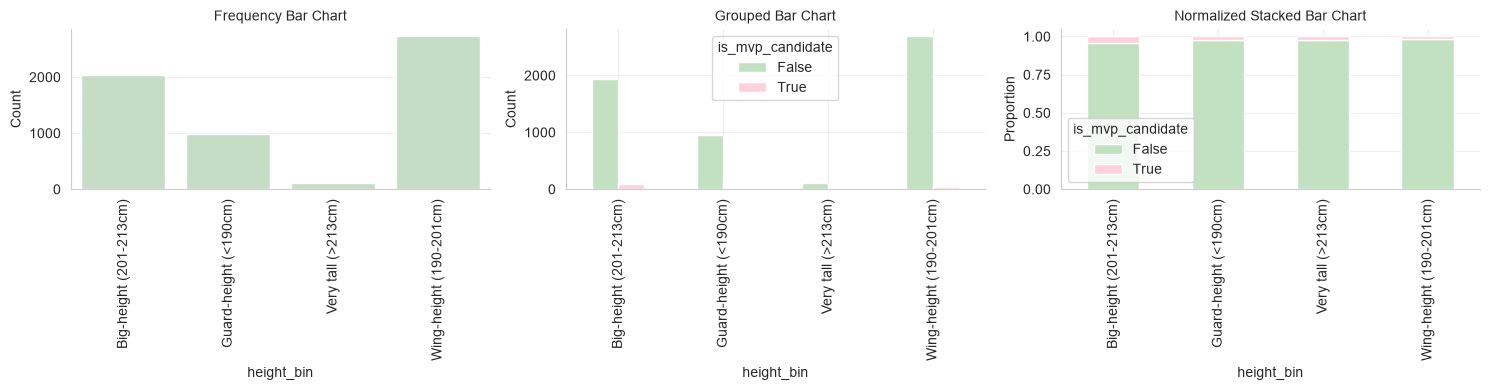

In [96]:
categorical_vs_target(df , categorical_columns[1] , target)

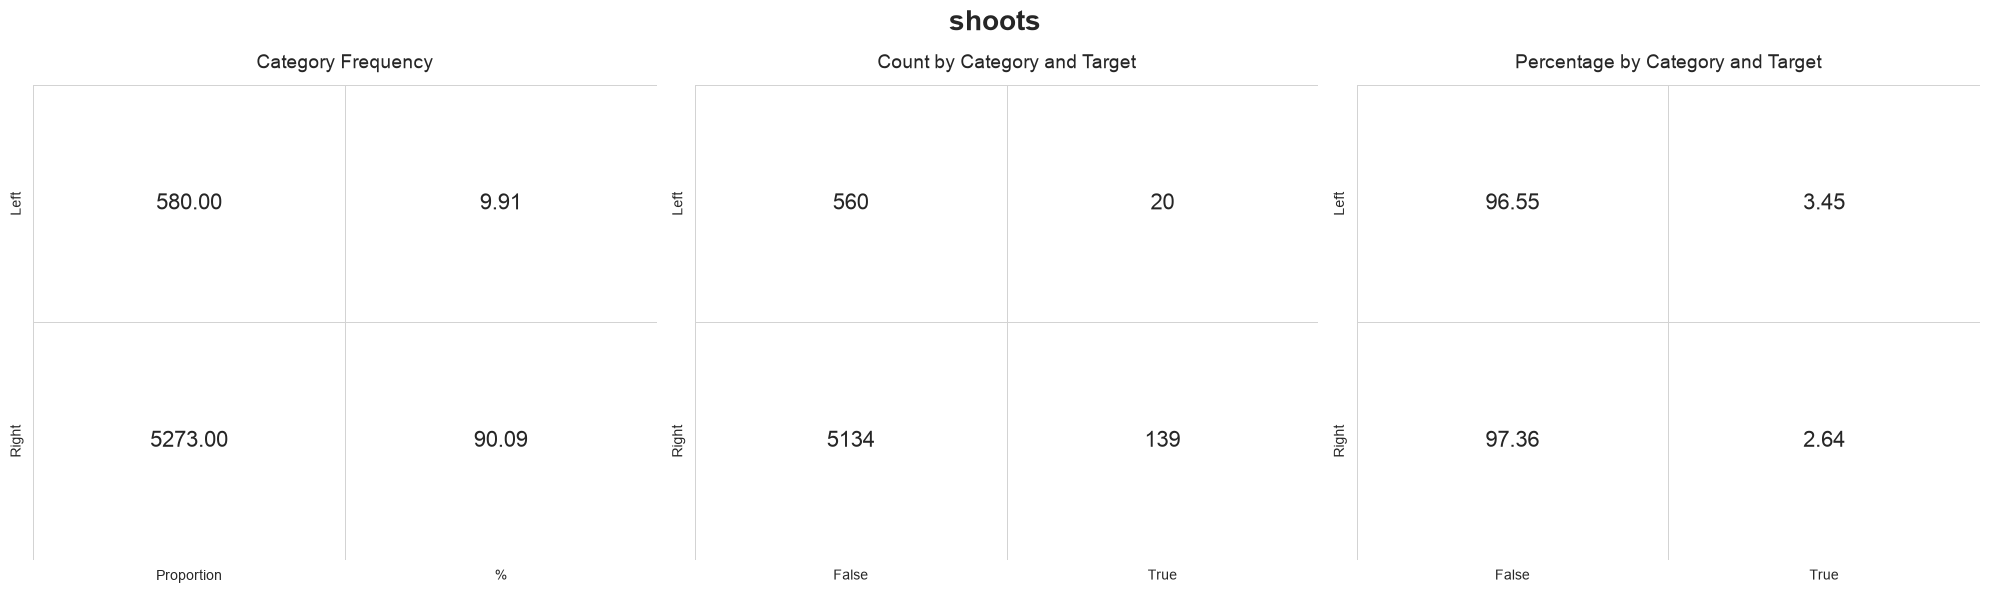

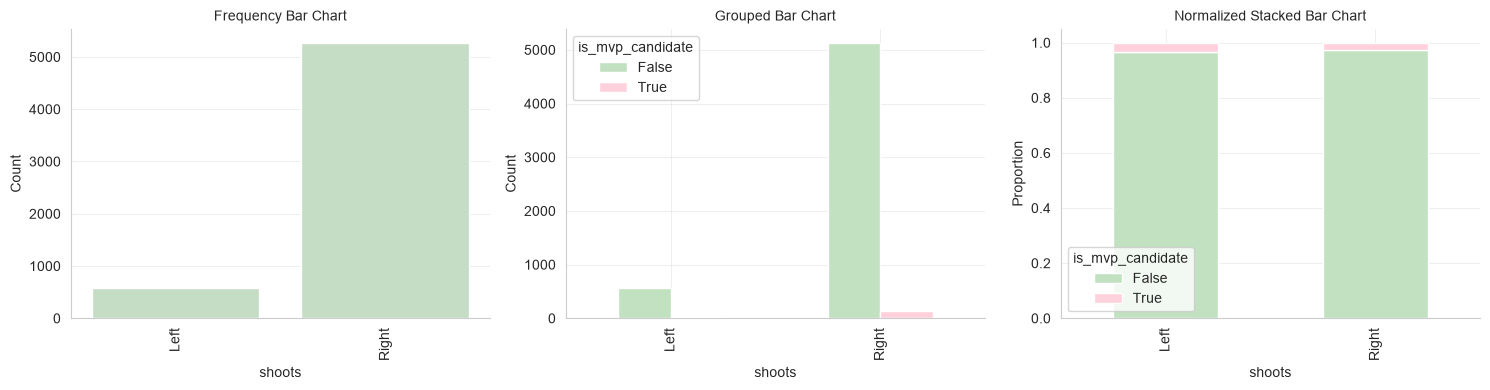

In [97]:
categorical_vs_target(df , categorical_columns[2] , target)

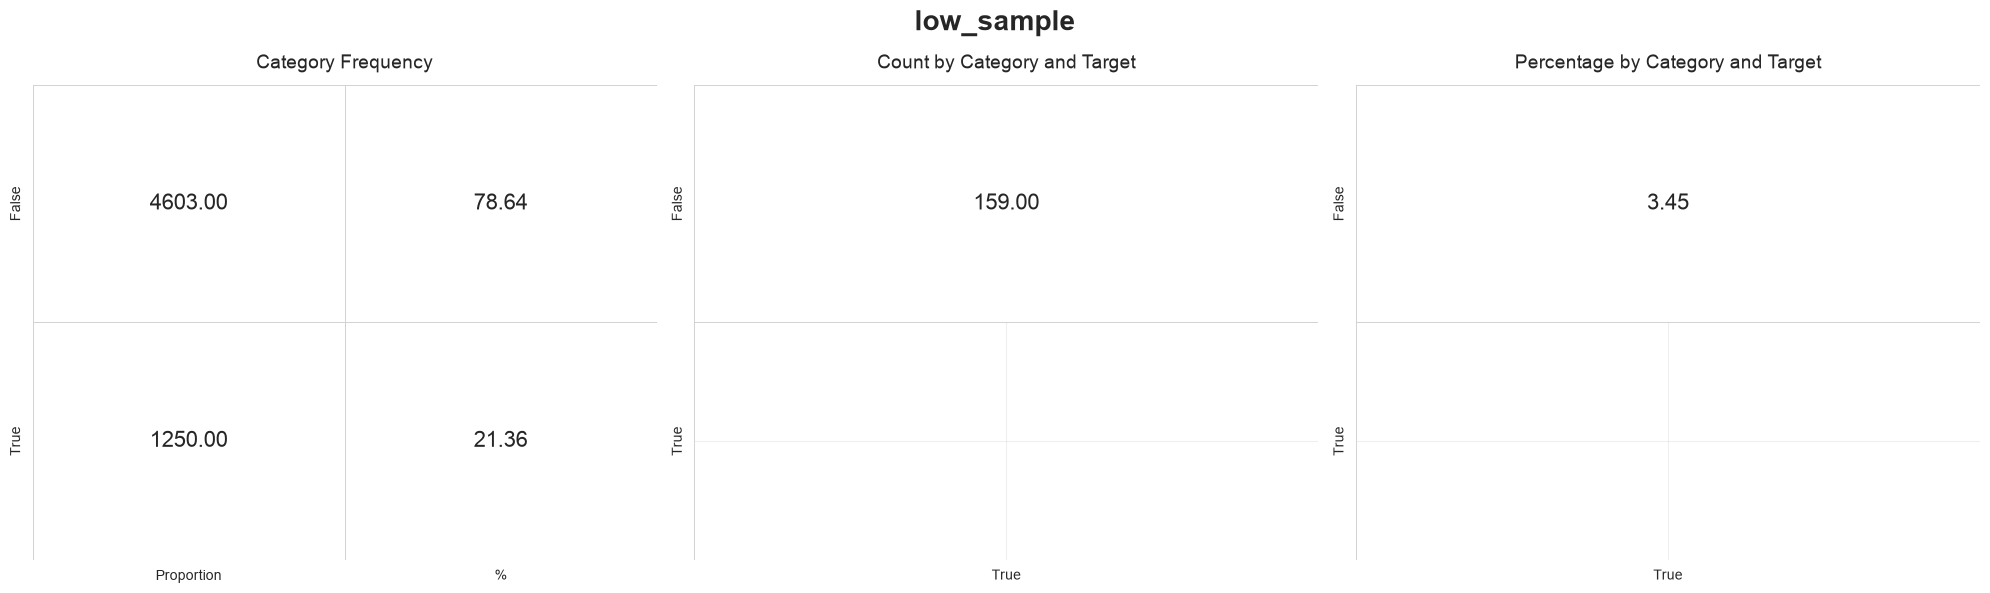

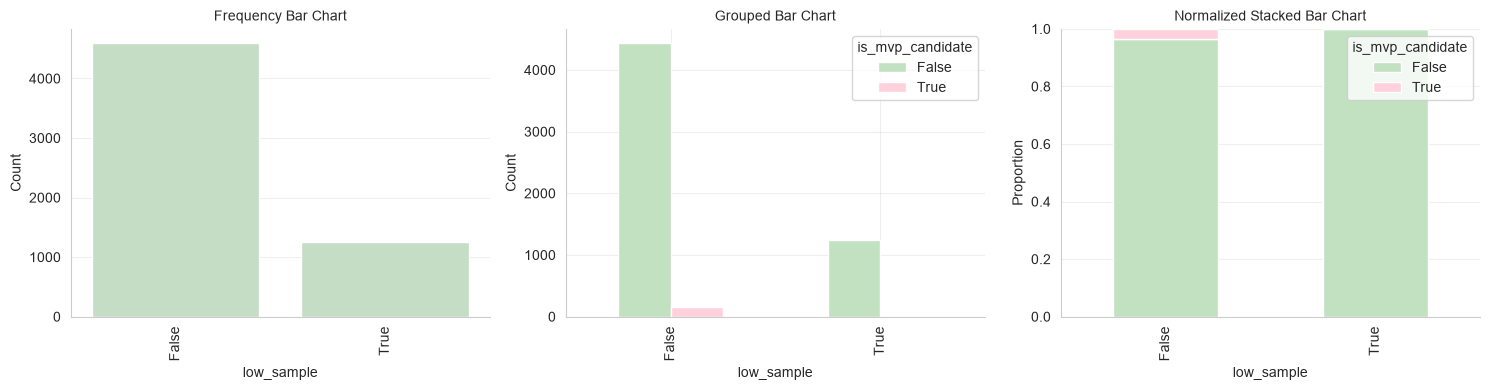

In [98]:
categorical_vs_target(df , categorical_columns[3] , target)

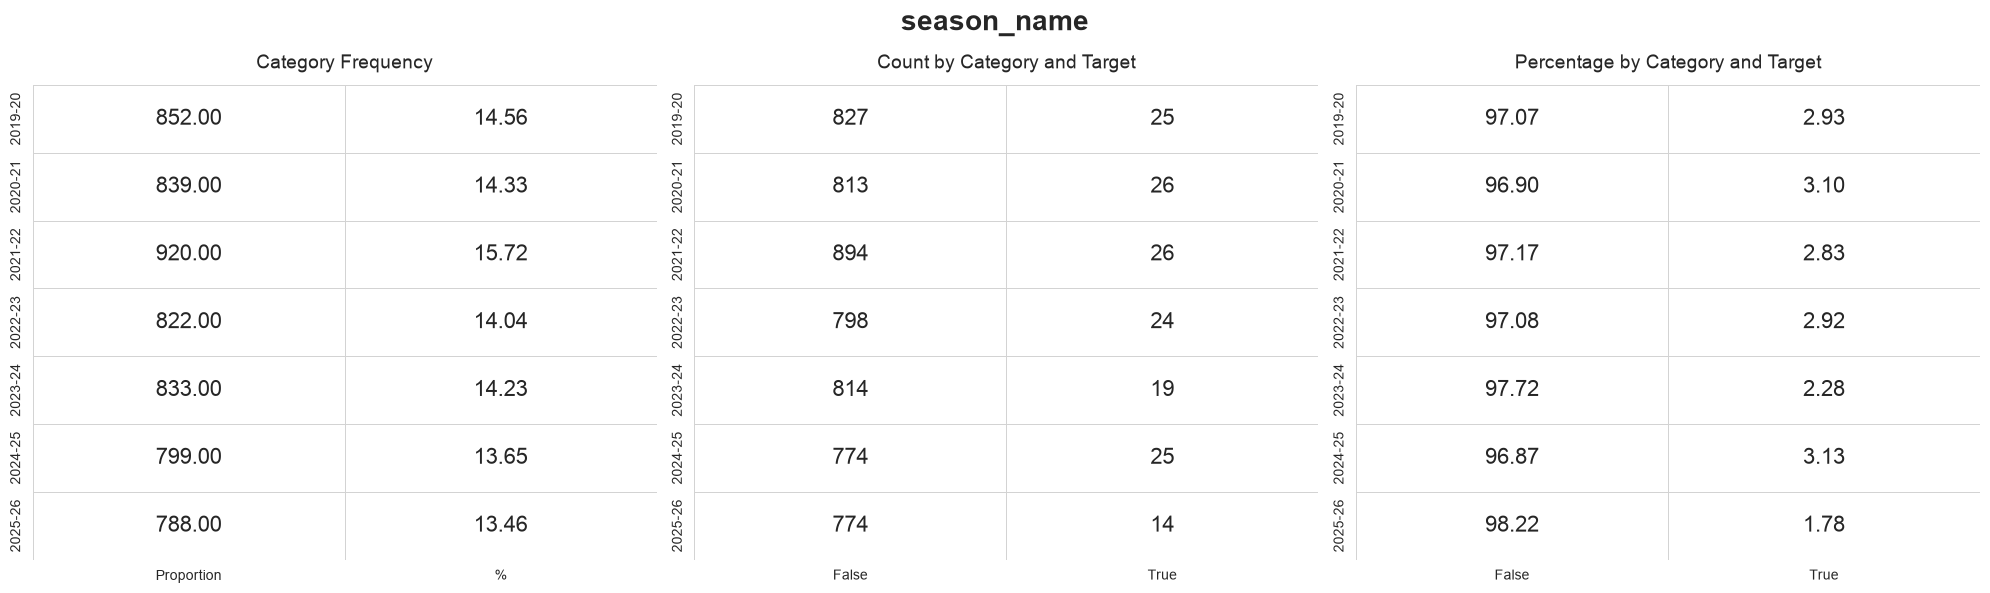

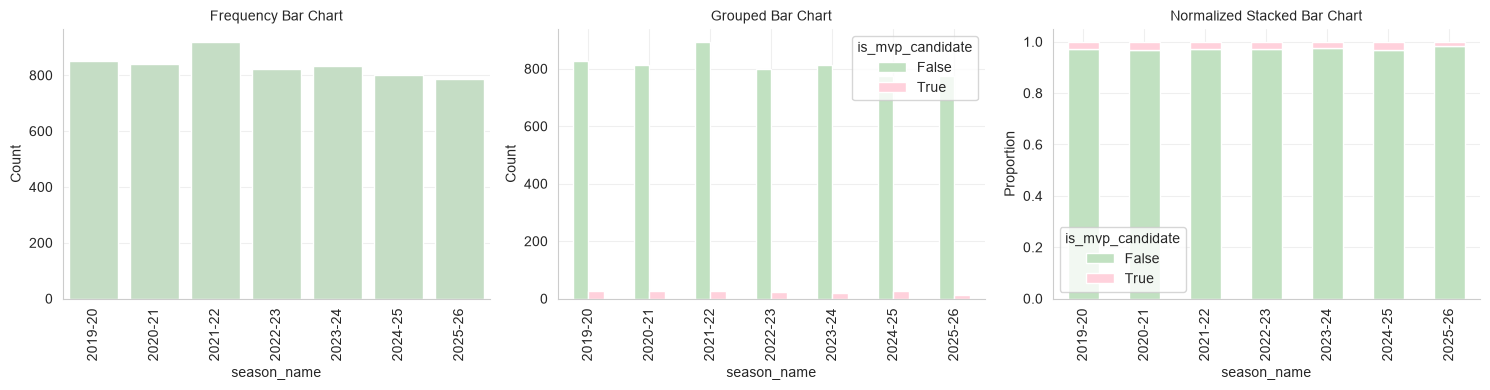

In [99]:
categorical_vs_target(df , categorical_columns[4] , target)

#### Continuous Features

For continuous features, we first examine each variable's **univariate distribution** using boxplots (with outlier counts via the IQR method), histograms with KDE overlays, and QQ-plots alongside the **Shapiro-Wilk test** for normality.

To analyze their relationship with the target variable, we compare group distributions using stacked histograms, per-group KDE plots, and per-bin proportion (100% stacked) plots.

Since most features are not normally distributed, we apply the **Mann–Whitney U test** — a non-parametric test that compares distributions without assuming normality — to assess whether the feature differs significantly between target groups.

In [82]:
def univariate_continuous_plots(data, col):
    """
    For numeric column in the DataFrame, plot:
    1. Boxplot with outlier counts (lower & upper)
    2. Histogram with KDE
    3. QQ Plot with Shapiro-Wilk normality test p-value

    Parameters:
    - data: pandas DataFrame
    - col: str
    """
    series = data[col].dropna()

    # -------- Outlier detection (IQR method) --------
    q1, q3 = np.percentile(series, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    n_lower = (series < lower_bound).sum()
    n_upper = (series > upper_bound).sum()

    # -------- Normality test (Shapiro-Wilk) --------
    # - H0 (null hypothesis): The data comes from a normal distribution.
    # - H1 (alternative hypothesis): The data does not come from a normal distribution.
    # Interpretation:
    #   If p-value < alpha (e.g., 0.05) → Reject H0 → Evidence suggests the data is NOT normally distributed.

    stat, p_value = stats.shapiro(series)
    
    # -------- Create subplots --------
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"Univariate Analysis: {col}", fontsize=14, fontweight="bold")

    # --- 1. Boxplot ---
    sns.boxplot(
    x=series,
    ax=axes[0],
    boxprops=dict(facecolor="lightgray"),   # box itself
    flierprops=dict(marker='o', markerfacecolor="#FFD1DC", markeredgecolor="#FFD1DC", alpha=0.7))
    axes[0].set_title("Boxplot")
    axes[0].text(0.95, 0.9, f"Lower: {n_lower}",
                 ha='right', va='center', transform=axes[0].transAxes,
                 fontsize=10)
    axes[0].text(0.95, 0.8, f"Upper: {n_upper}",
                 ha='right', va='center', transform=axes[0].transAxes,
                 fontsize=10)
    axes[0].text(0.95, 0.7, f"%: {((n_upper+n_lower)/len(data[col])).round(4)*100}",
                 ha='right', va='center', transform=axes[0].transAxes,
                 fontsize=10)
    
    # --- 2. Histogram + KDE ---
    sns.histplot(series, kde=True, ax=axes[1], color="#C1E1C1", edgecolor="black")
    axes[1].set_title("Histogram + KDE")

    # --- 3. QQ Plot ---
    (osm, osr), (slope, intercept, r) = stats.probplot(series, dist="norm")
    
    # Scatter points (gray)
    axes[2].scatter(osm, osr, color="gray", alpha=0.7)
    
    # Reference line (pink)
    x = np.linspace(min(osm), max(osm), 100)
    axes[2].plot(x, slope * x + intercept, color="#FFD1DC", linewidth=2)
    
    axes[2].set_title(f"QQ Plot\nShapiro p = {p_value:.4f}")
        
    plt.tight_layout()
    plt.show()

In [87]:
def plot_continuous_vs_target(df, feature, target, bins=20):
    """
    Draws 3 plots (in one row) to compare a continuous feature vs a binary categorical target.

    Parameters:
    - df: pandas DataFrame
    - feature: str -> name of continuous feature
    - target: str -> name of categorical/binary target (0/1 or No/Yes)
    - bins: int -> number of bins for histogram
    """

    classes = df[target].unique()
    if len(classes) != 2:
        raise ValueError("Target must be binary for this function.")

    class0, class1 = classes
    colors = {class0: "#C1E1C1", class1: "#FFD1DC"}

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    fig.suptitle(f"Multivariate Analysis: {feature}", fontsize=16, fontweight="bold")
    sns.set_style("whitegrid")

    # --- 1. Stacked Histogram ---
    axes[0].hist(
        [df.loc[df[target]==class0, feature],
         df.loc[df[target]==class1, feature]],
        bins=bins,
        stacked=True,
        color=[colors[class0], colors[class1]],
        label=[f"{class0}", f"{class1}"]
    )
    axes[0].set_title(f"Stacked Histogram of {feature}")
    axes[0].legend(title=target)

    # --- 2. KDE Plot ---
    sns.kdeplot(
        data=df, x=feature, hue=target,
        fill=True, common_norm=False,
        palette=colors, alpha=0.4, ax=axes[1]
    )
    axes[1].set_title(f"KDE of {feature} by {target}")

    # --- 3. Per-bin 100% Stacked Histogram (each bar sums to 1) ---
    edges = np.histogram_bin_edges(df[feature].to_numpy(), bins=bins)
    
    vals0 = df.loc[df[target] == class0, feature].to_numpy()
    vals1 = df.loc[df[target] == class1, feature].to_numpy()
    
    cnt0, _ = np.histogram(vals0, bins=edges)
    cnt1, _ = np.histogram(vals1, bins=edges)
    
    tot = cnt0 + cnt1
    tot_safe = np.where(tot == 0, 1, tot) 
    
    prop0 = cnt0 / tot_safe
    prop1 = cnt1 / tot_safe
    
    centers = (edges[:-1] + edges[1:]) / 2
    widths  = np.diff(edges)
    
    axes[2].bar(centers, prop0, width=widths, color=colors[class0],
                edgecolor="black", linewidth=0.5, align='center', label=str(class0))
    axes[2].bar(centers, prop1, width=widths, bottom=prop0, color=colors[class1],
                edgecolor="black", linewidth=0.5, align='center', label=str(class1))
    
    axes[2].set_ylim(0, 1)
    axes[2].set_ylabel("Proportion")
    axes[2].set_title(f"Per-bin Proportions (100% Stacked) of {feature}")
    axes[2].legend(title=target)

    plt.tight_layout()
    plt.show()

In [88]:
def analyze_continuous_vs_binary(df, feature, target, bins=20, n_perm=1000, alpha=0.05):
    """
    Visualize and statistically analyze the relationship between a continuous feature
    and a binary target variable.
    
    Steps:
    1. Plot relationship with target (via plot_continuous_vs_target).
    2. Plot univariate distributions (via univariate_continuous_plots).
    3. Perform statistical non-parametric tests:
       - Mann–Whitney U test

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset containing feature and target.
    feature : str
        Name of the continuous feature column.
    target : str
        Name of the binary target column.
    bins : int
        Number of bins for histograms.
    n_perm : int
        Number of permutations for permutation test.
    """
    
    # --- 1 & 2. Plotting (two rows of plots) ---
    univariate_continuous_plots(df, feature)
    plot_continuous_vs_target(df, feature, target, bins=bins)   
    plt.show()
    
    # --- 3. Statistical tests ---
    # Split data into two groups based on target
    categories = df[target].unique()
    print(feature)
    group0 = df.loc[df[target] == categories[0], feature].dropna()
    group1 = df.loc[df[target] == categories[1], feature].dropna()

    # Mann–Whitney U
    u_stat, p_mwu = stats.mannwhitneyu(group0, group1, alternative="two-sided")
    print(f" Mann–Whitney U test: Tests whether the distribution of {feature} differs between groups {categories[0]} and {categories[1]}.")
    print(f"    p = {p_mwu:.4f} → {'Significant difference detected' if p_mwu < alpha else 'No significant difference detected'}.\n")

In [100]:
numeric_columns = [
    'age', 'games', 'games_started', 'minutes',
    'win_shares', 'ws_per_48', 'bpm', 'vorp',
    'experience', 'height_cm', 'weight_kg', 'bmi',
    'agility', 'innate_ability'
]

/Users/parsa/Desktop/projects/BOOTCAMP/PROJECT3/venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5853.
  res = hypotest_fun_out(*samples, **kwds)


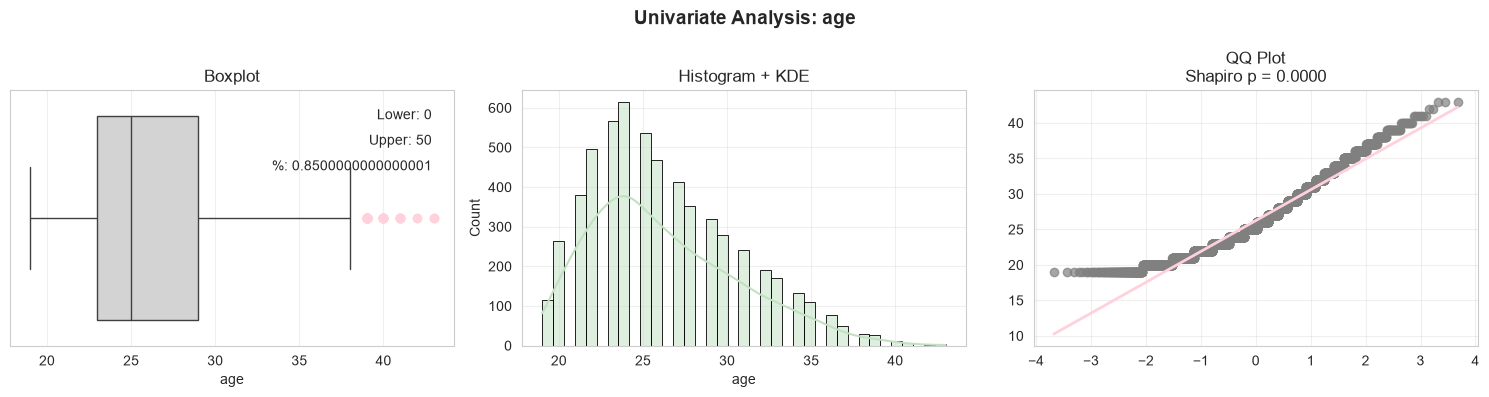

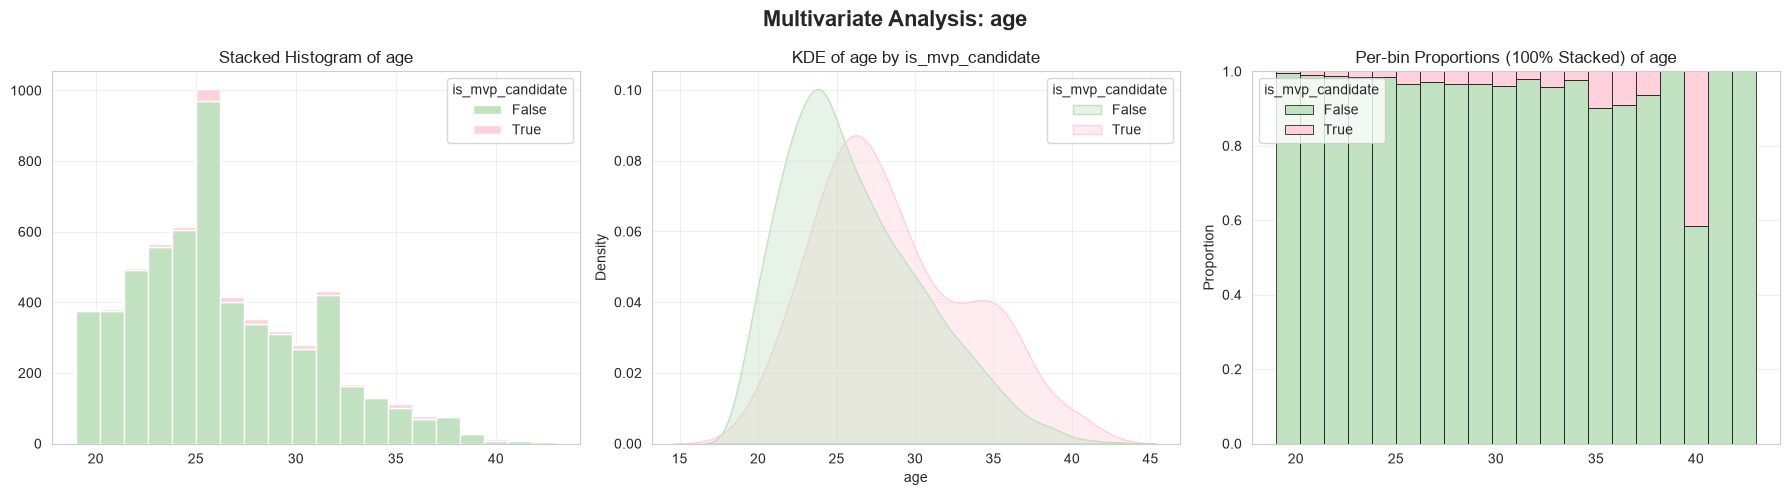

age
 Mann–Whitney U test: Tests whether the distribution of age differs between groups False and True.
    p = 0.0000 → Significant difference detected.



In [101]:
analyze_continuous_vs_binary(df, numeric_columns[0], target)

/Users/parsa/Desktop/projects/BOOTCAMP/PROJECT3/venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5853.
  res = hypotest_fun_out(*samples, **kwds)


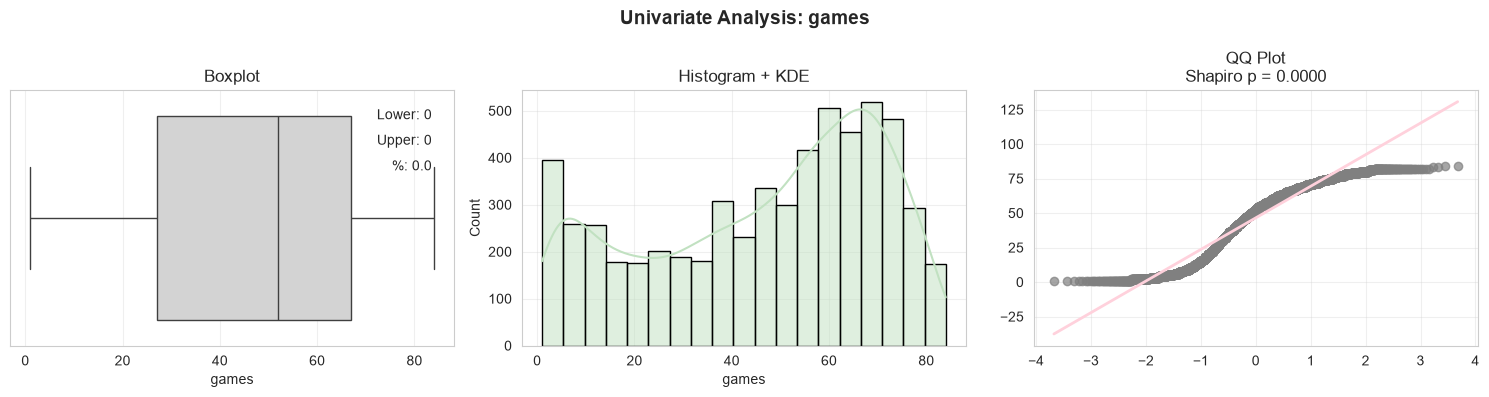

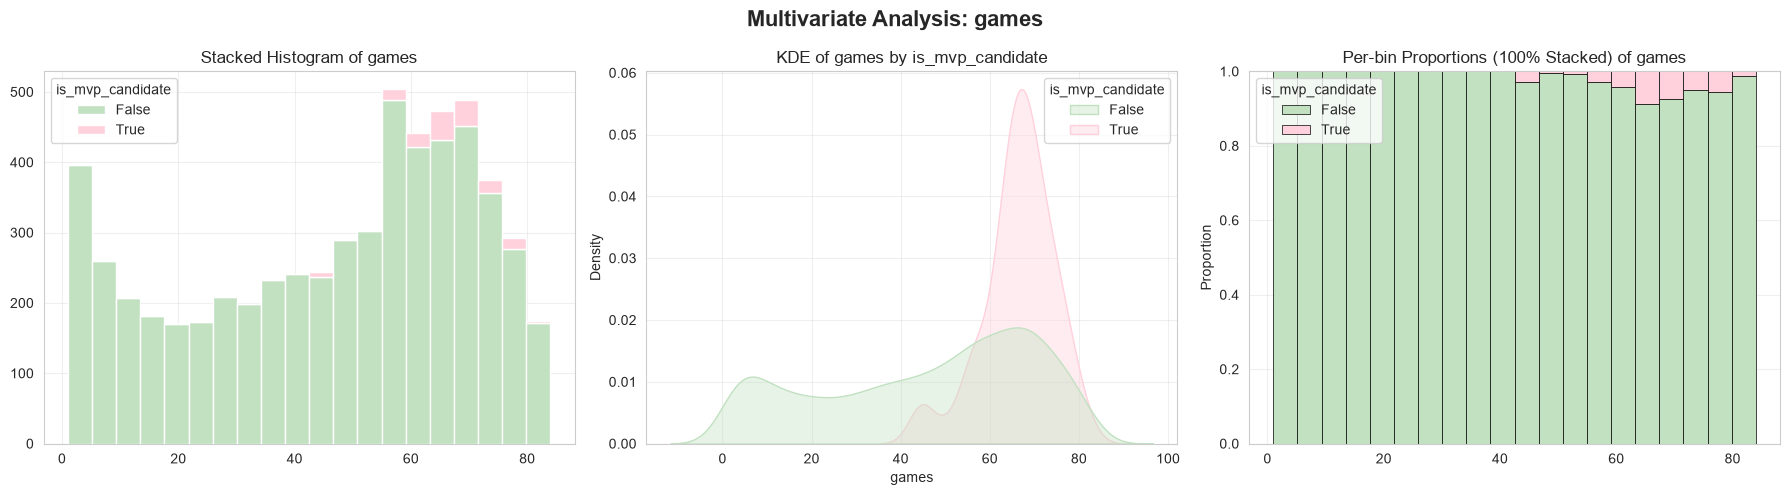

games
 Mann–Whitney U test: Tests whether the distribution of games differs between groups False and True.
    p = 0.0000 → Significant difference detected.



In [102]:
analyze_continuous_vs_binary(df, numeric_columns[1], target)

/Users/parsa/Desktop/projects/BOOTCAMP/PROJECT3/venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5853.
  res = hypotest_fun_out(*samples, **kwds)


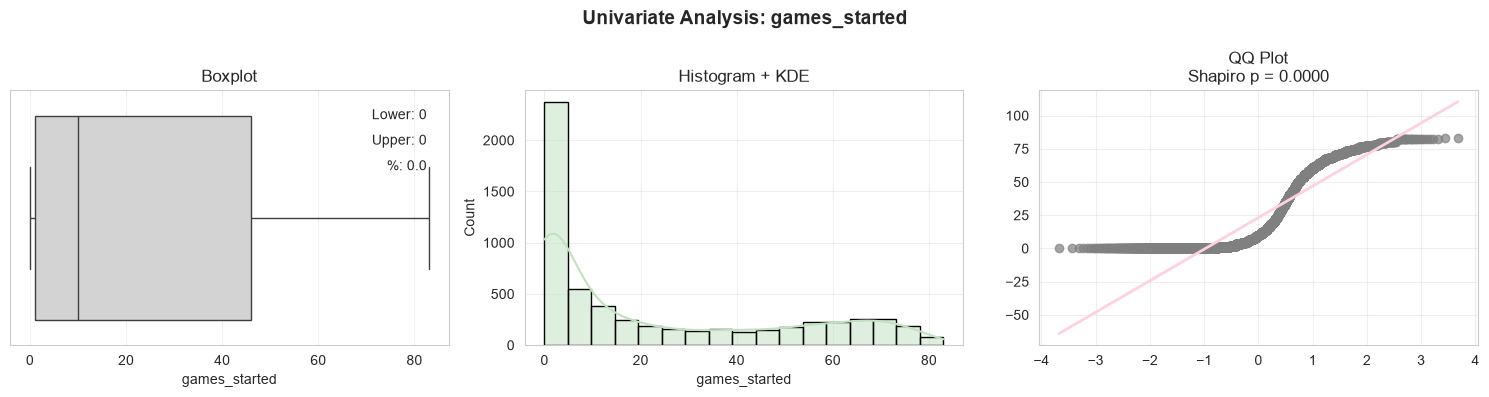

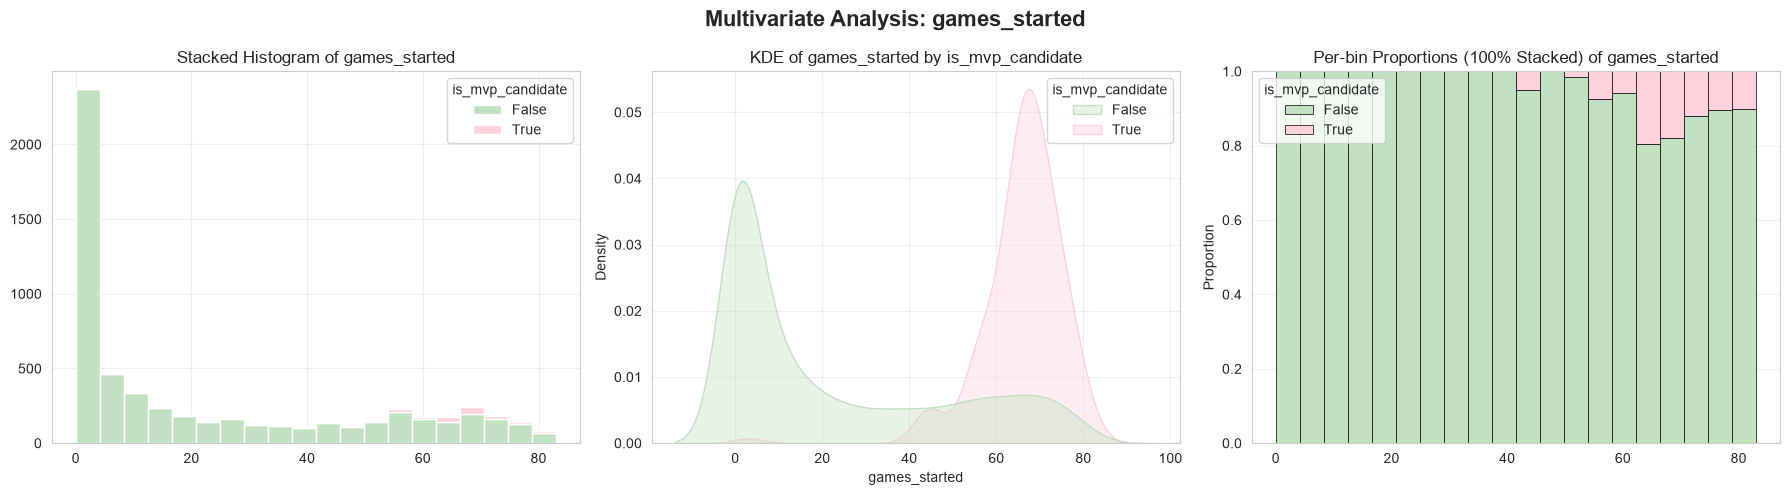

games_started
 Mann–Whitney U test: Tests whether the distribution of games_started differs between groups False and True.
    p = 0.0000 → Significant difference detected.



In [103]:
analyze_continuous_vs_binary(df, numeric_columns[2], target)

/Users/parsa/Desktop/projects/BOOTCAMP/PROJECT3/venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5853.
  res = hypotest_fun_out(*samples, **kwds)


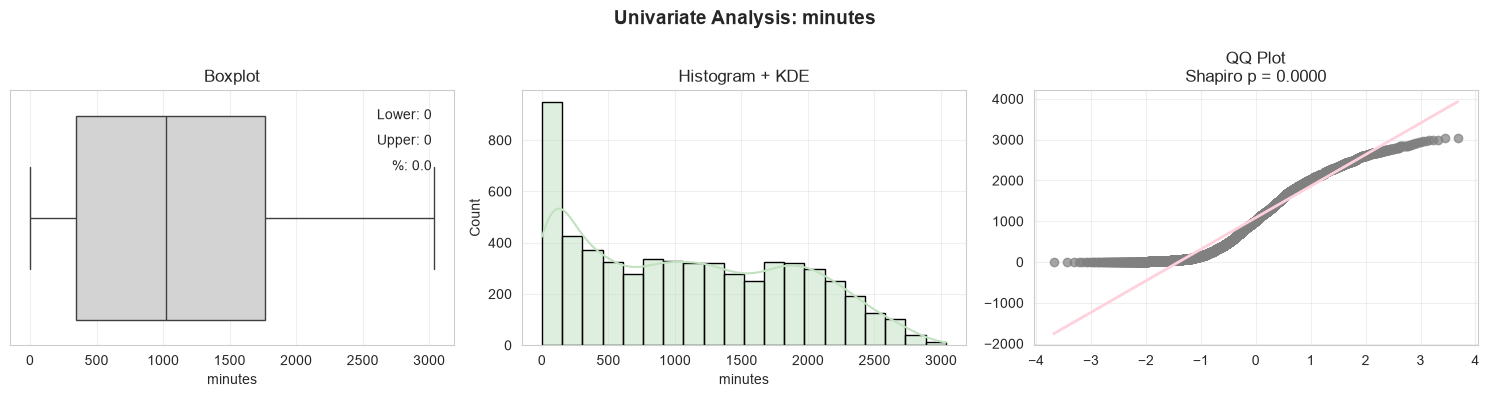

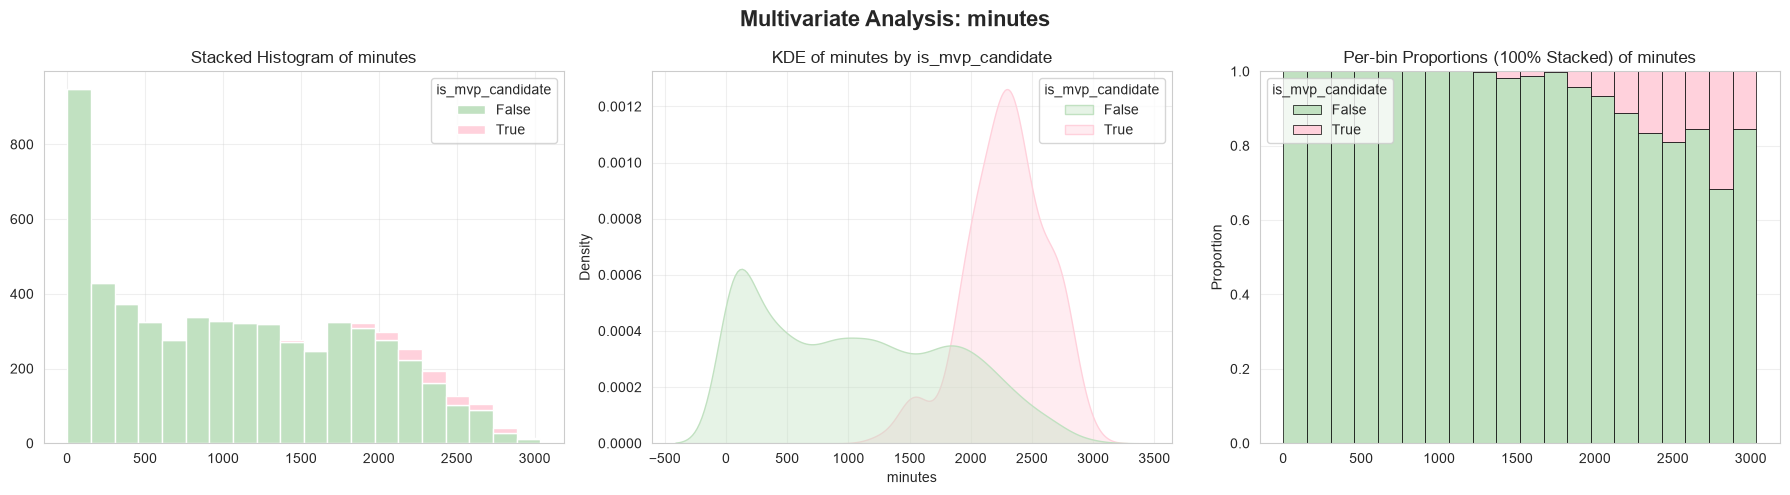

minutes
 Mann–Whitney U test: Tests whether the distribution of minutes differs between groups False and True.
    p = 0.0000 → Significant difference detected.



In [104]:
analyze_continuous_vs_binary(df, numeric_columns[3], target)

/Users/parsa/Desktop/projects/BOOTCAMP/PROJECT3/venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5853.
  res = hypotest_fun_out(*samples, **kwds)


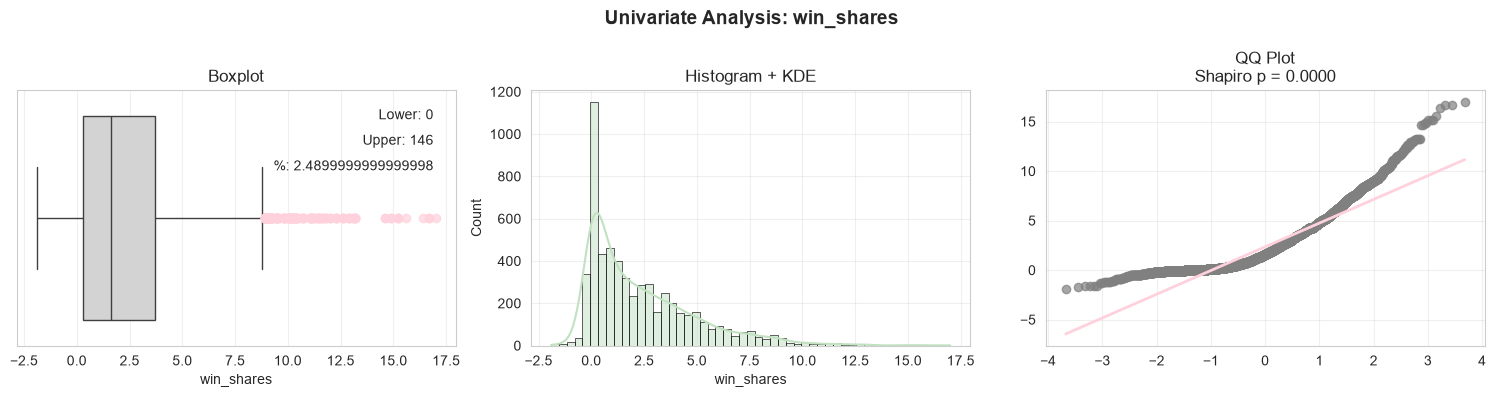

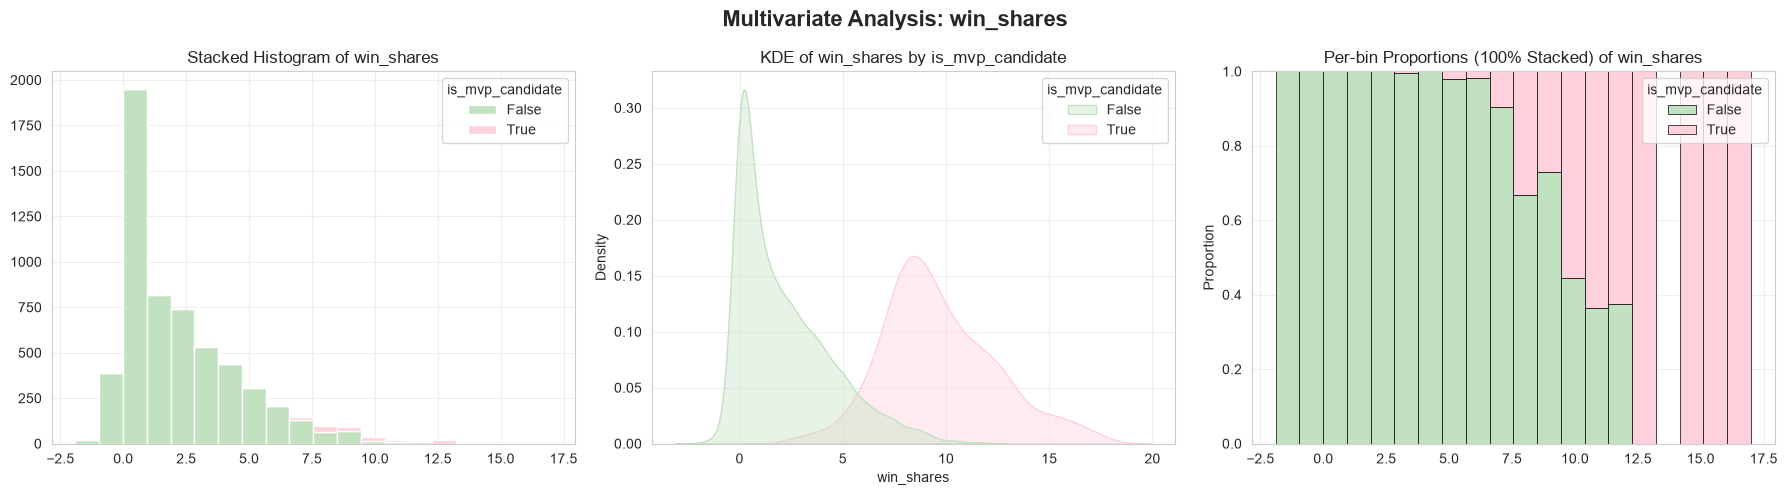

win_shares
 Mann–Whitney U test: Tests whether the distribution of win_shares differs between groups False and True.
    p = 0.0000 → Significant difference detected.



In [105]:
analyze_continuous_vs_binary(df, numeric_columns[4], target)

/Users/parsa/Desktop/projects/BOOTCAMP/PROJECT3/venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5853.
  res = hypotest_fun_out(*samples, **kwds)


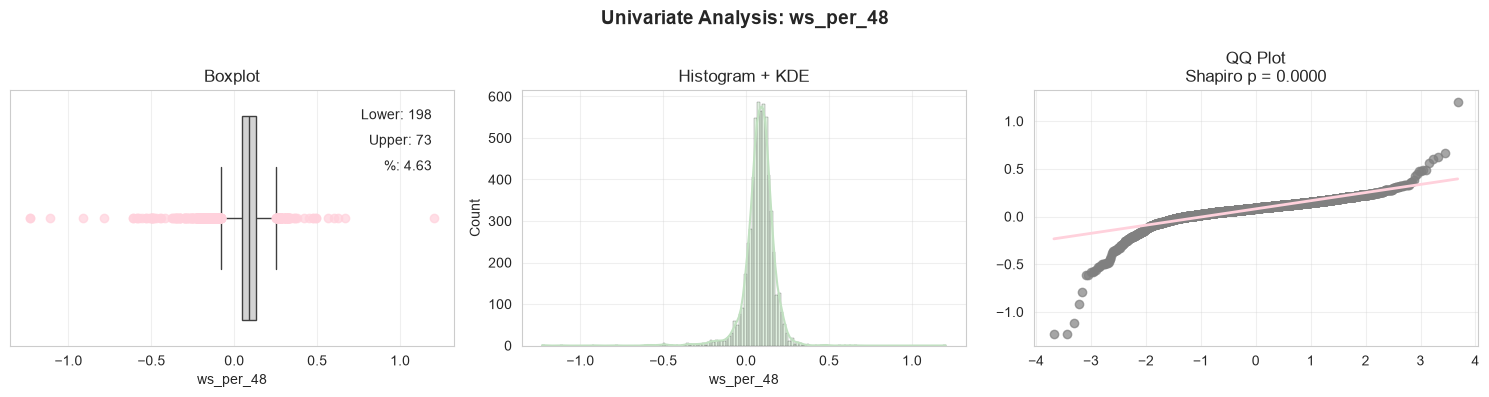

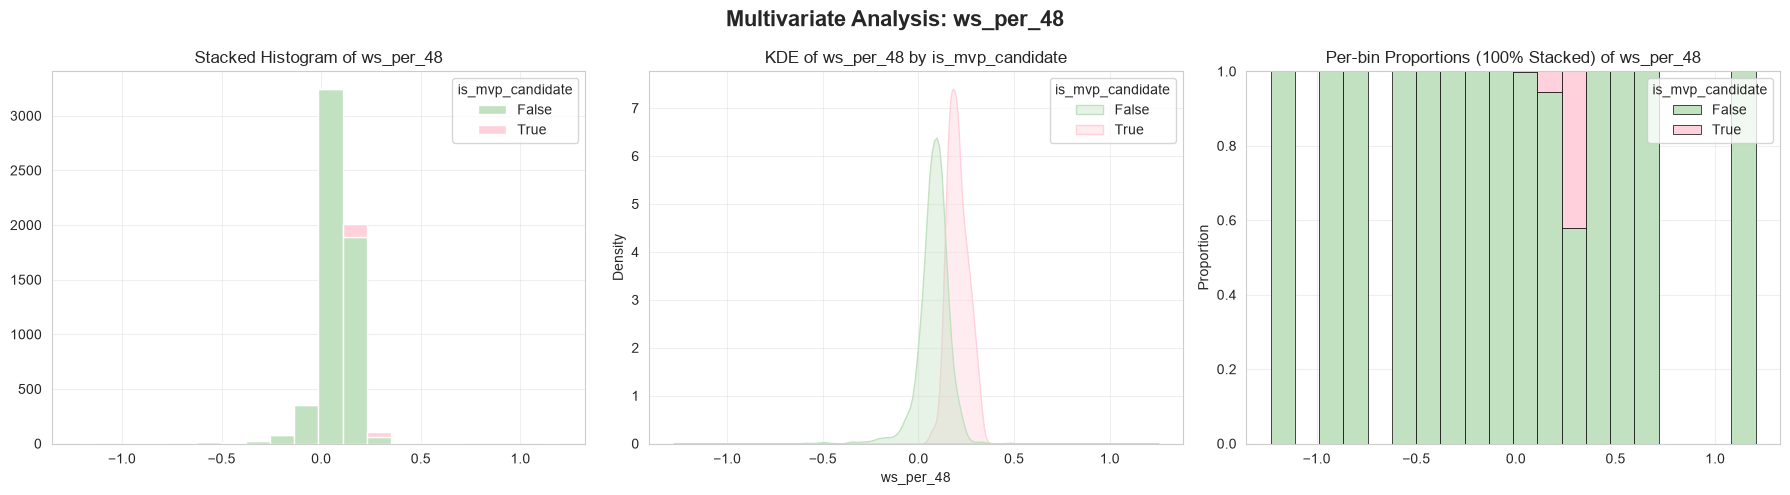

ws_per_48
 Mann–Whitney U test: Tests whether the distribution of ws_per_48 differs between groups False and True.
    p = 0.0000 → Significant difference detected.



In [106]:
analyze_continuous_vs_binary(df, numeric_columns[5], target)

/Users/parsa/Desktop/projects/BOOTCAMP/PROJECT3/venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5853.
  res = hypotest_fun_out(*samples, **kwds)


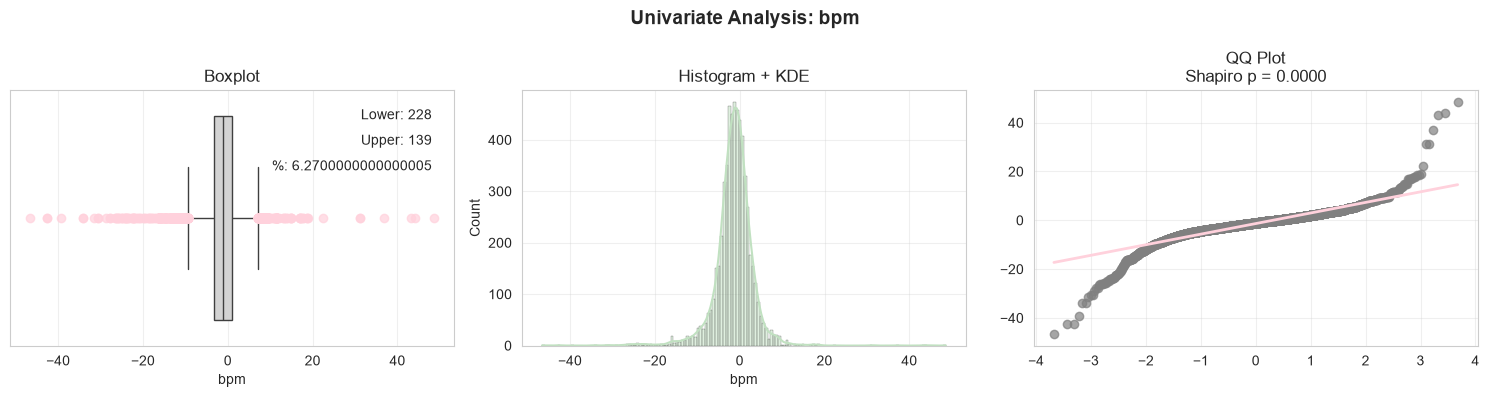

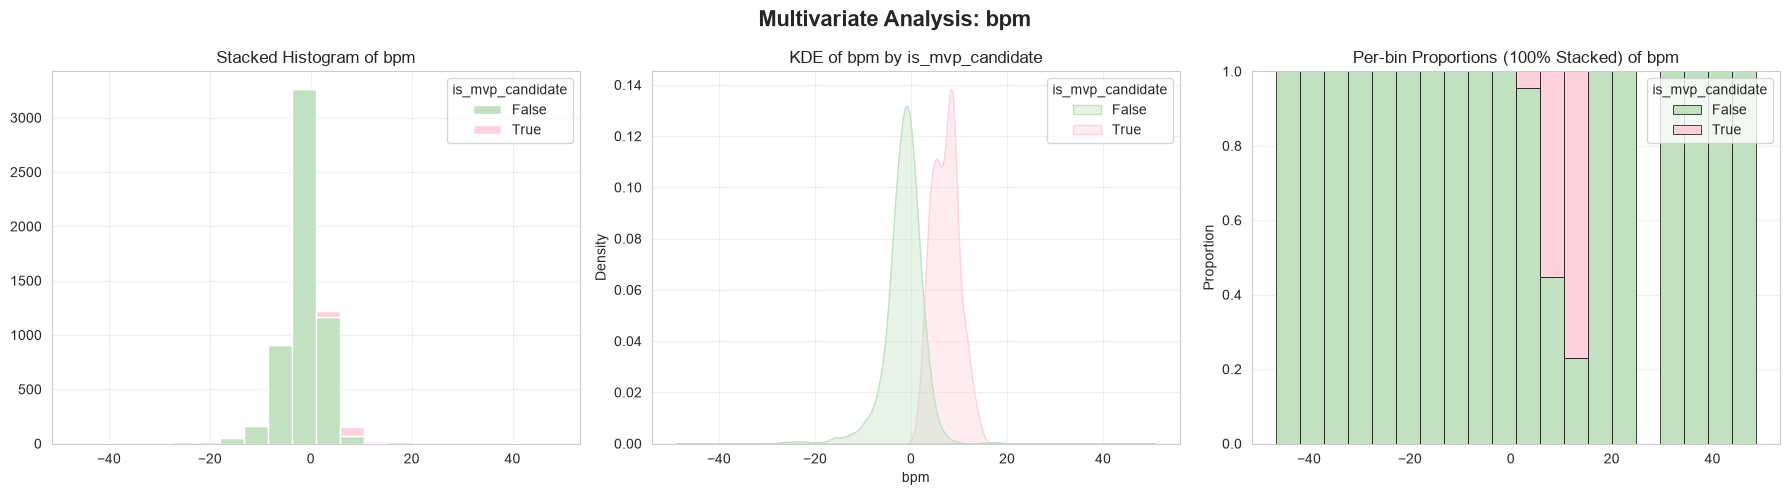

bpm
 Mann–Whitney U test: Tests whether the distribution of bpm differs between groups False and True.
    p = 0.0000 → Significant difference detected.



In [107]:
analyze_continuous_vs_binary(df, numeric_columns[6], target)

/Users/parsa/Desktop/projects/BOOTCAMP/PROJECT3/venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5853.
  res = hypotest_fun_out(*samples, **kwds)


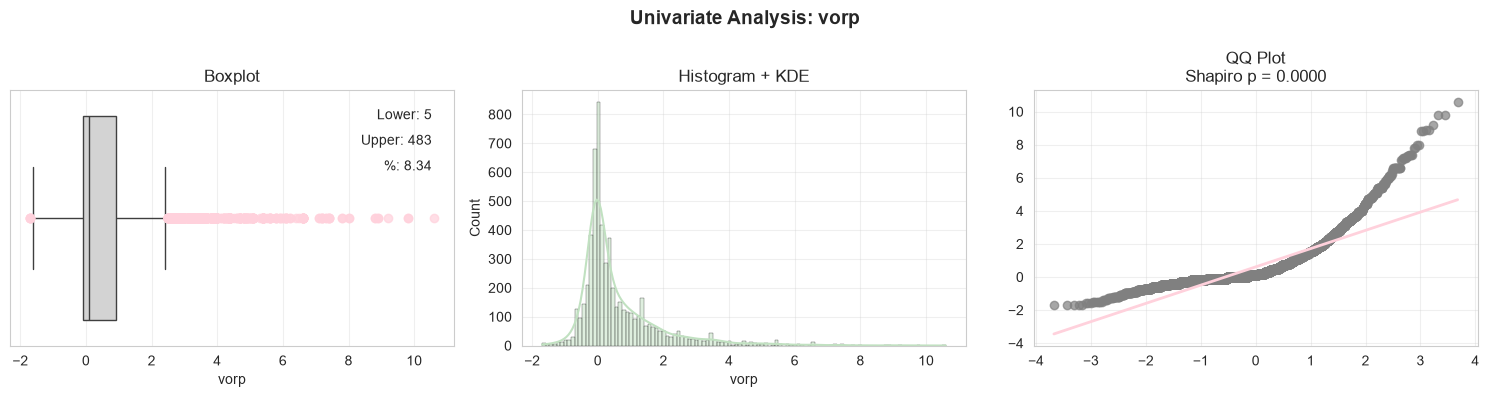

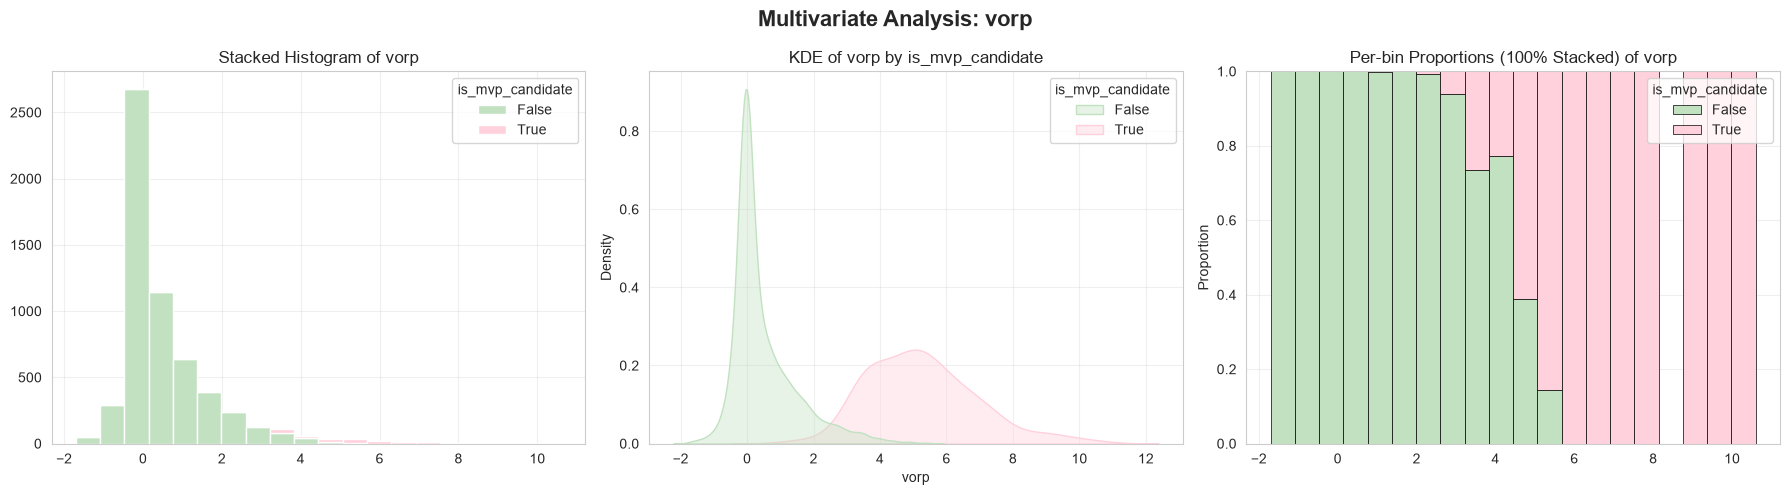

vorp
 Mann–Whitney U test: Tests whether the distribution of vorp differs between groups False and True.
    p = 0.0000 → Significant difference detected.



In [108]:
analyze_continuous_vs_binary(df, numeric_columns[7], target)

/Users/parsa/Desktop/projects/BOOTCAMP/PROJECT3/venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5853.
  res = hypotest_fun_out(*samples, **kwds)


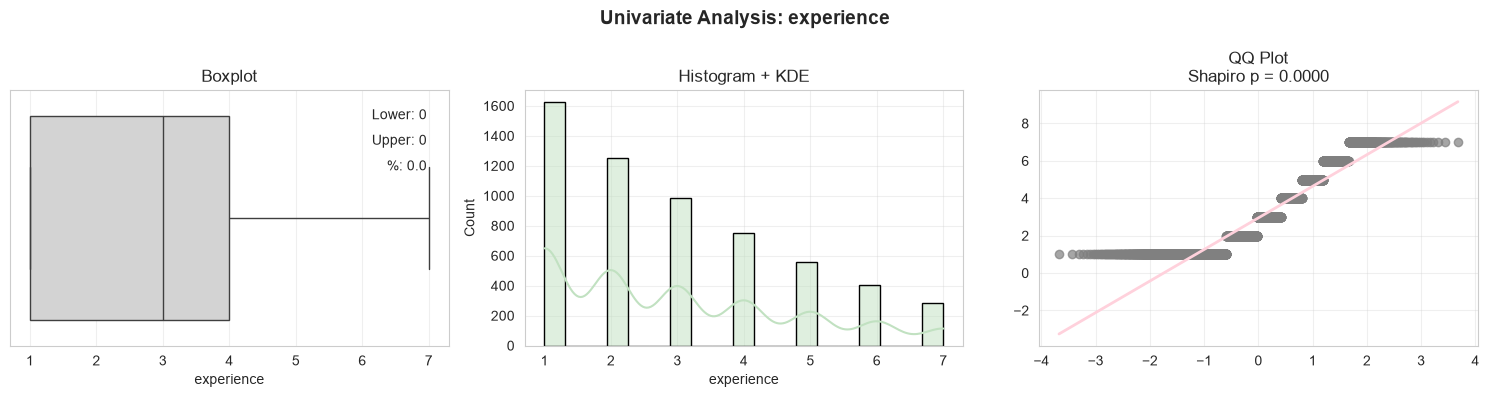

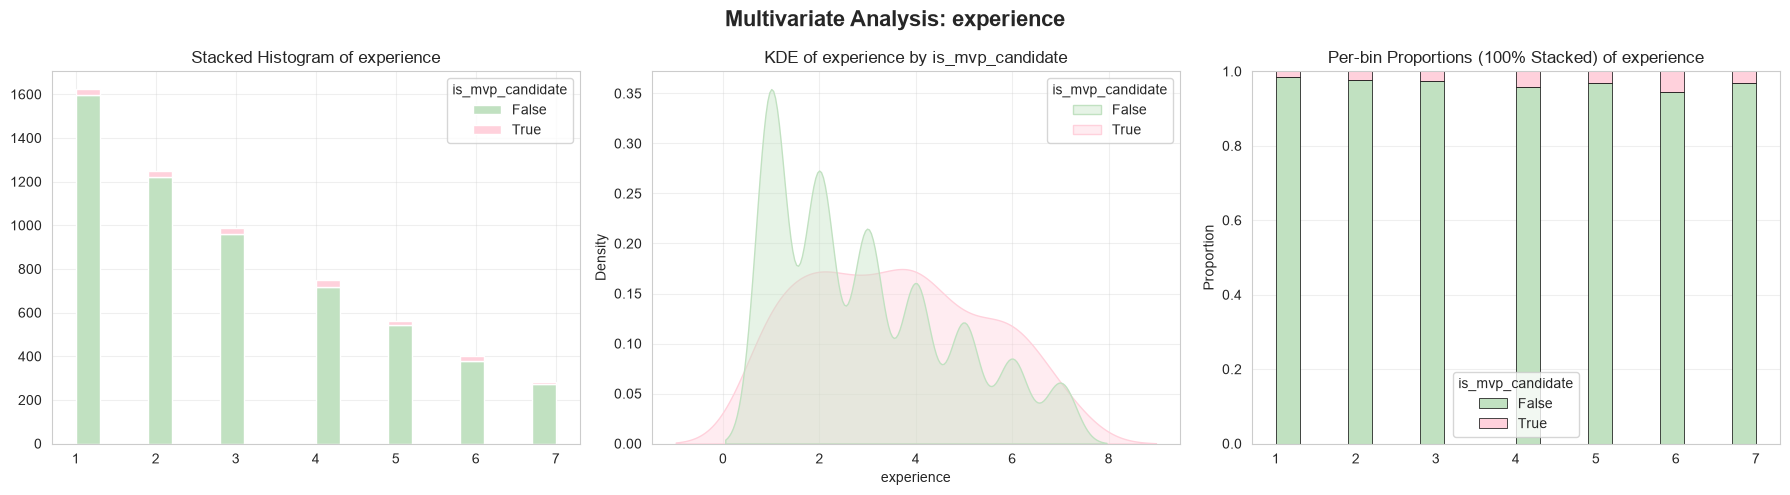

experience
 Mann–Whitney U test: Tests whether the distribution of experience differs between groups False and True.
    p = 0.0000 → Significant difference detected.



In [109]:
analyze_continuous_vs_binary(df, numeric_columns[8], target)

/Users/parsa/Desktop/projects/BOOTCAMP/PROJECT3/venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5853.
  res = hypotest_fun_out(*samples, **kwds)


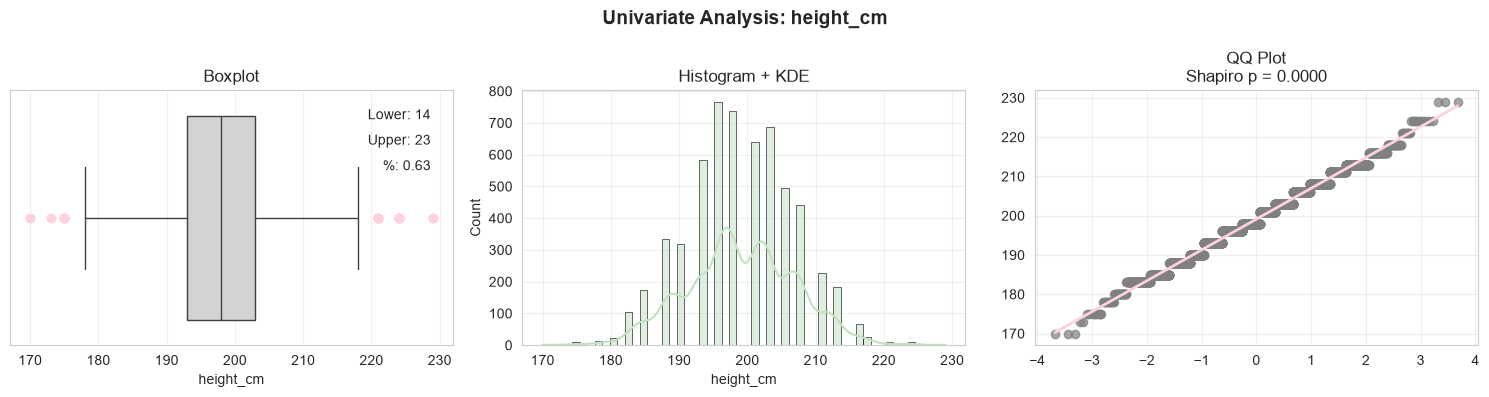

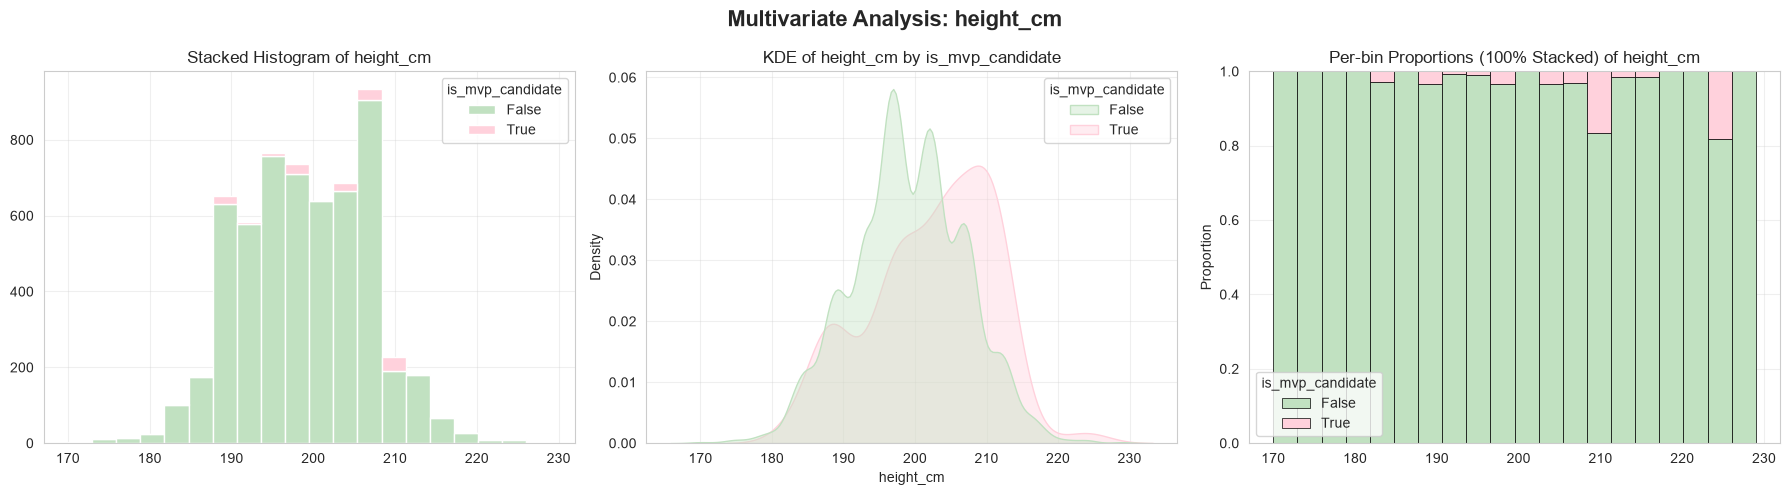

height_cm
 Mann–Whitney U test: Tests whether the distribution of height_cm differs between groups False and True.
    p = 0.0000 → Significant difference detected.



In [110]:
analyze_continuous_vs_binary(df, numeric_columns[9], target)

/Users/parsa/Desktop/projects/BOOTCAMP/PROJECT3/venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5853.
  res = hypotest_fun_out(*samples, **kwds)


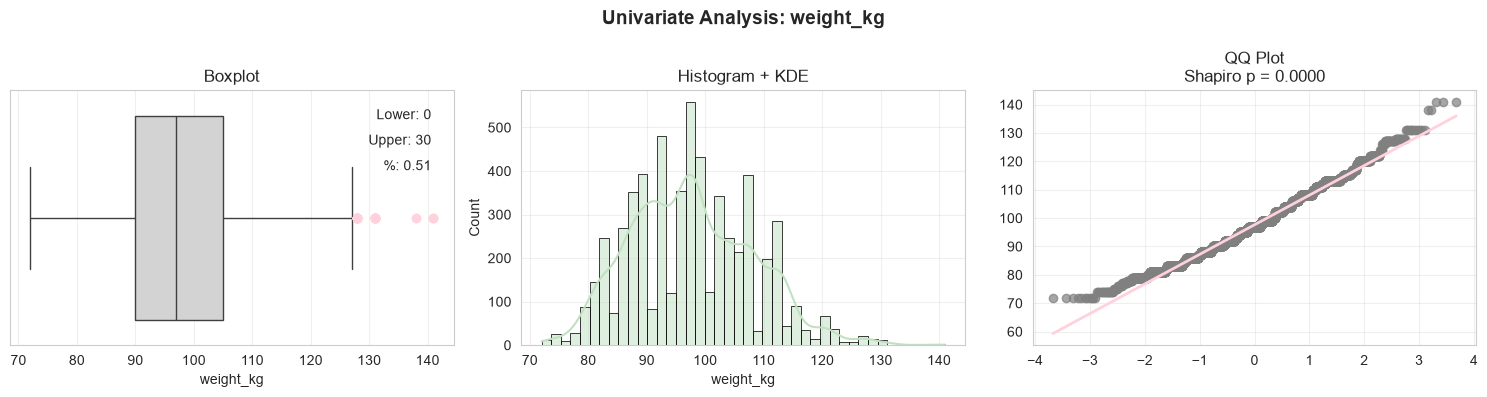

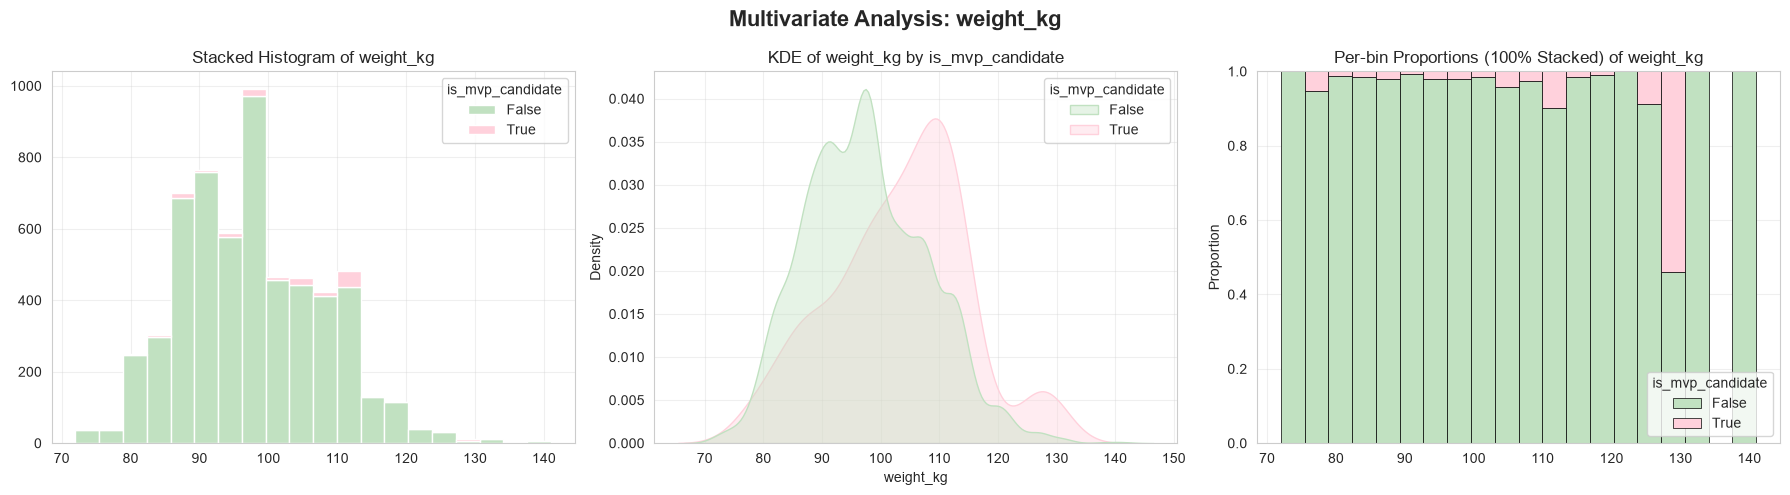

weight_kg
 Mann–Whitney U test: Tests whether the distribution of weight_kg differs between groups False and True.
    p = 0.0000 → Significant difference detected.



In [111]:
analyze_continuous_vs_binary(df, numeric_columns[10], target)

/Users/parsa/Desktop/projects/BOOTCAMP/PROJECT3/venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5853.
  res = hypotest_fun_out(*samples, **kwds)


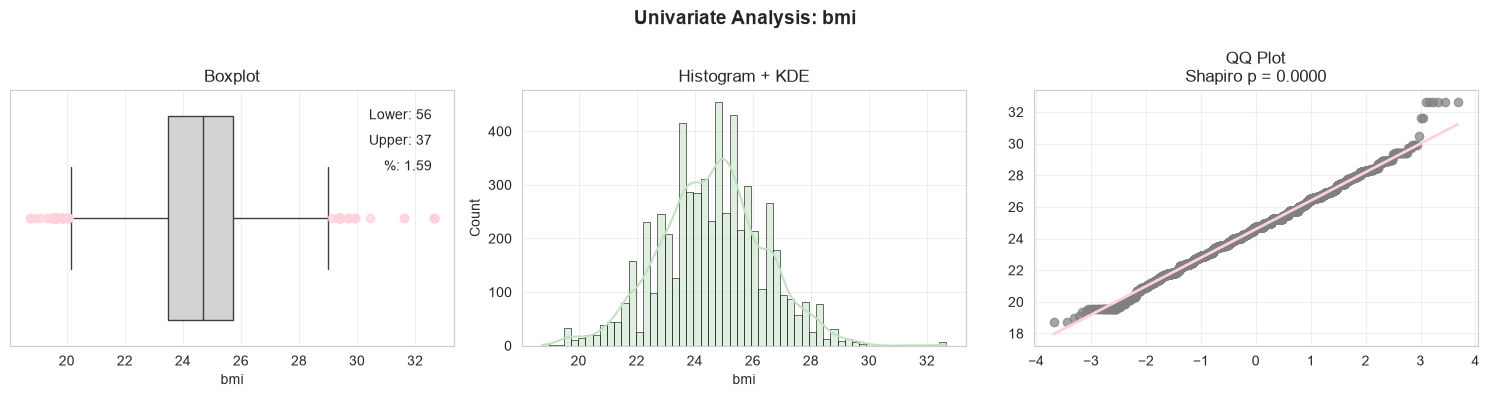

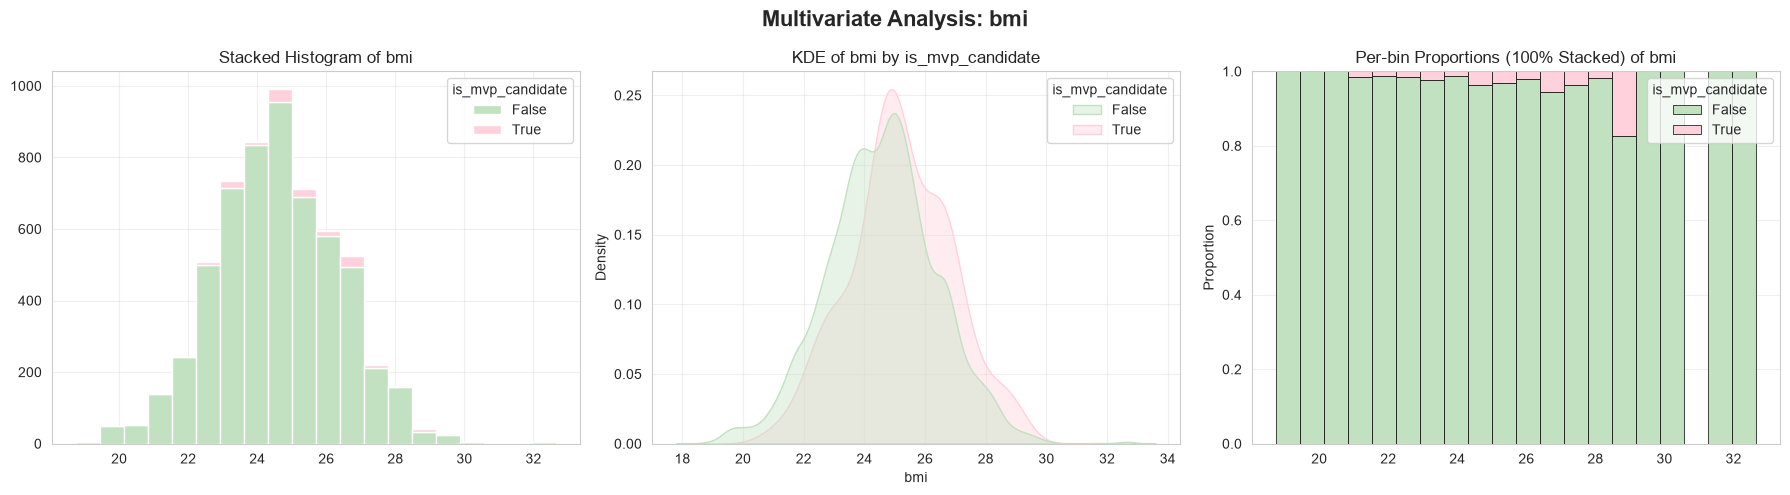

bmi
 Mann–Whitney U test: Tests whether the distribution of bmi differs between groups False and True.
    p = 0.0000 → Significant difference detected.



In [112]:
analyze_continuous_vs_binary(df, numeric_columns[11], target)

/Users/parsa/Desktop/projects/BOOTCAMP/PROJECT3/venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5853.
  res = hypotest_fun_out(*samples, **kwds)


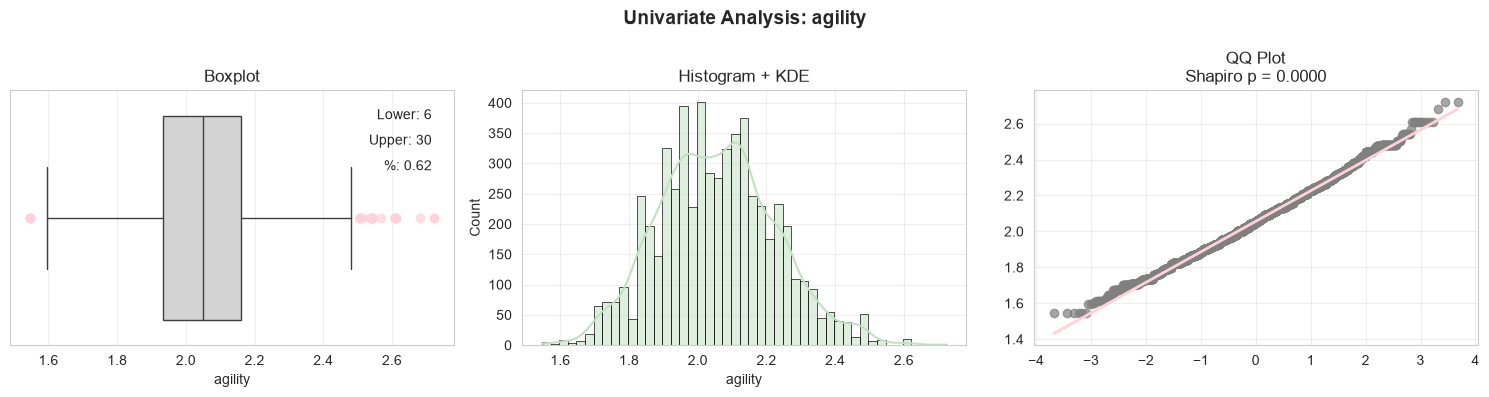

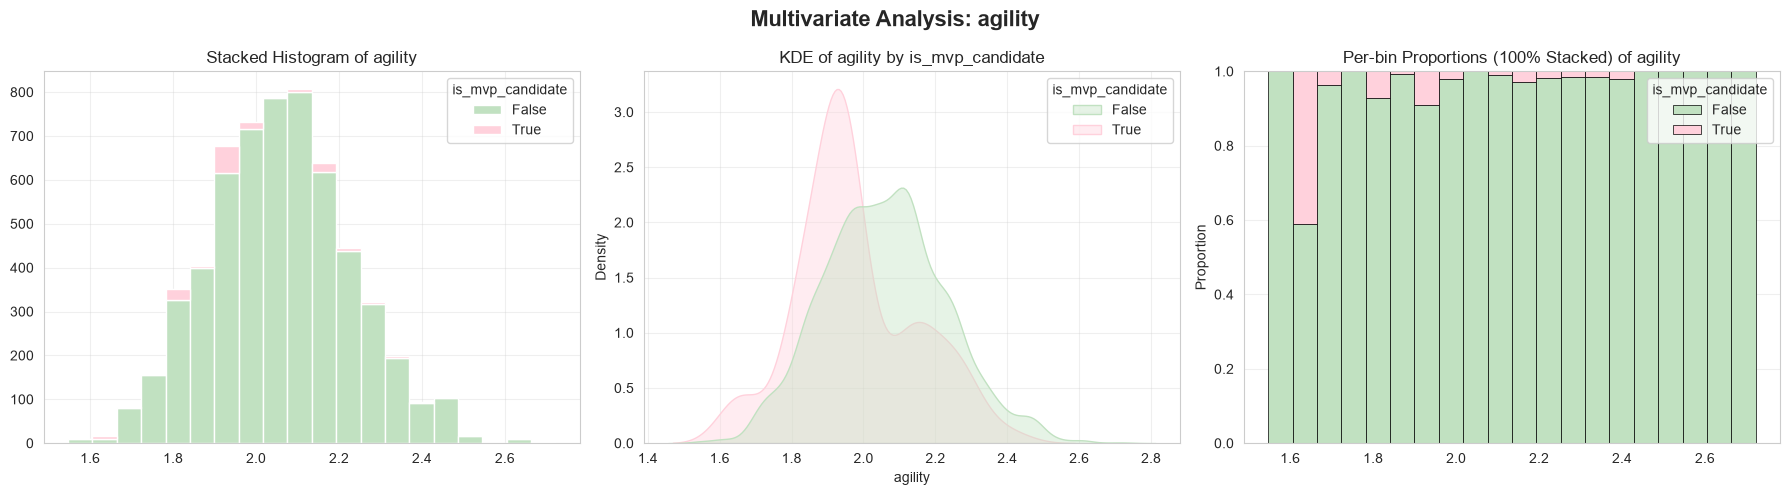

agility
 Mann–Whitney U test: Tests whether the distribution of agility differs between groups False and True.
    p = 0.0000 → Significant difference detected.



In [113]:
analyze_continuous_vs_binary(df, numeric_columns[12], target)

/Users/parsa/Desktop/projects/BOOTCAMP/PROJECT3/venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:601: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5853.
  res = hypotest_fun_out(*samples, **kwds)


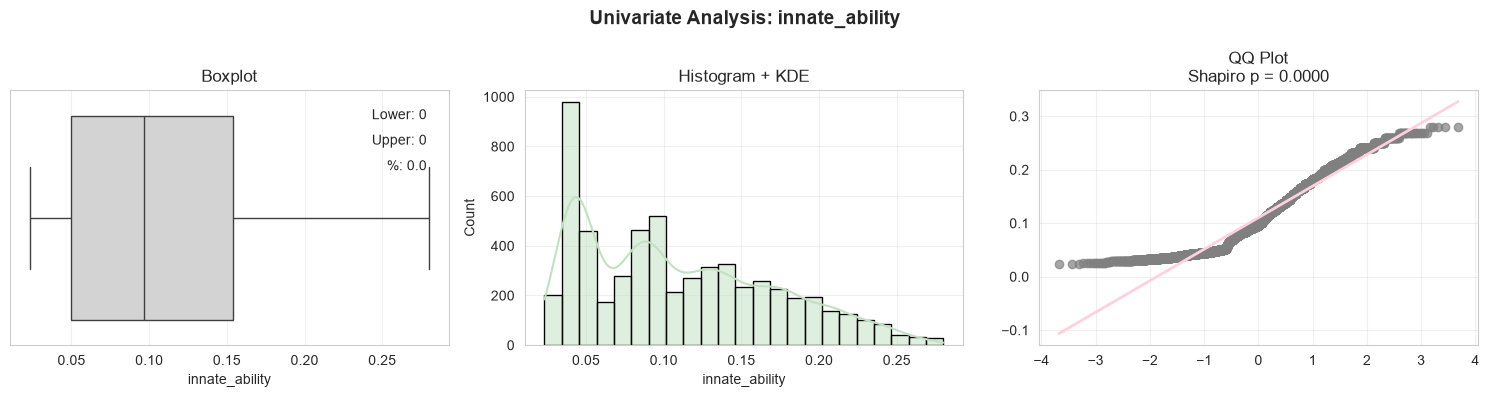

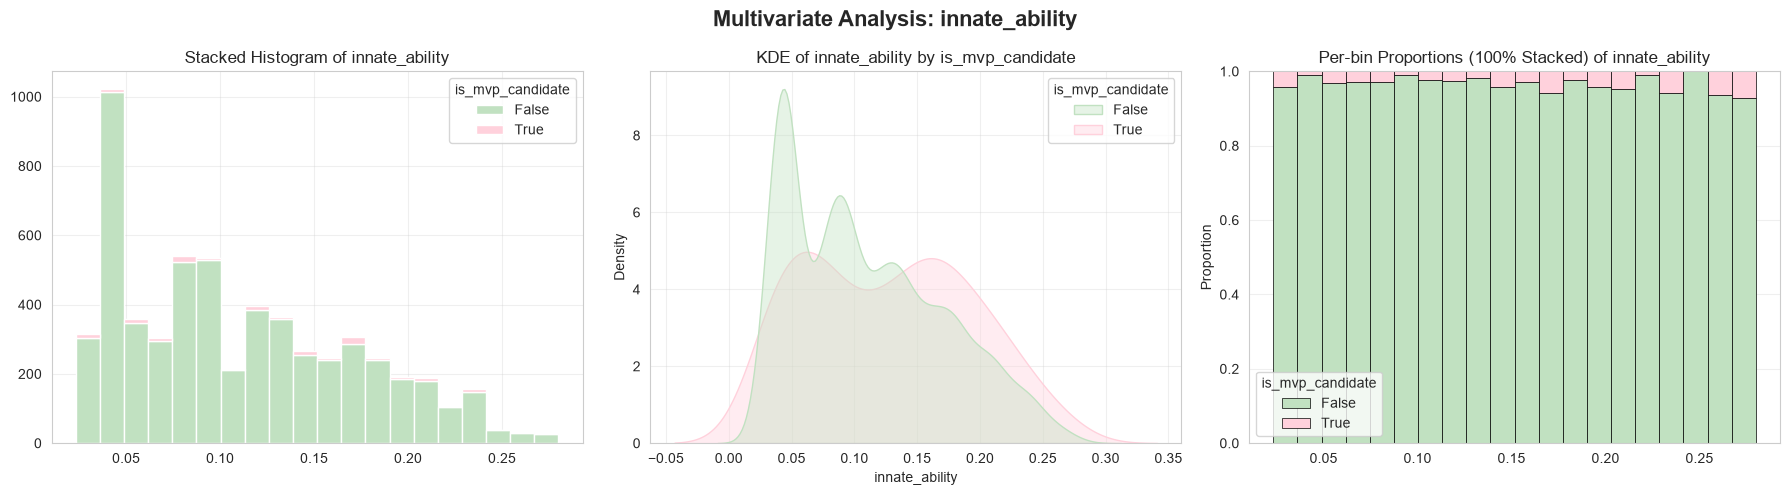

innate_ability
 Mann–Whitney U test: Tests whether the distribution of innate_ability differs between groups False and True.
    p = 0.0018 → Significant difference detected.



In [114]:
analyze_continuous_vs_binary(df, numeric_columns[13], target)

## Part 1 — General EDA

In [4]:
print('Rows:', len(df), '| Unique players:', df['player_id'].nunique(), '| Seasons:', df['season_name'].nunique())
print()
print(df.isna().sum()[df.isna().sum() > 0])

Rows: 4266 | Unique players: 963 | Seasons: 5

birth_date       10
birth_place      10
mvp_rank       4168
mvp_share      4146
dtype: int64


### Distributions of core numeric features

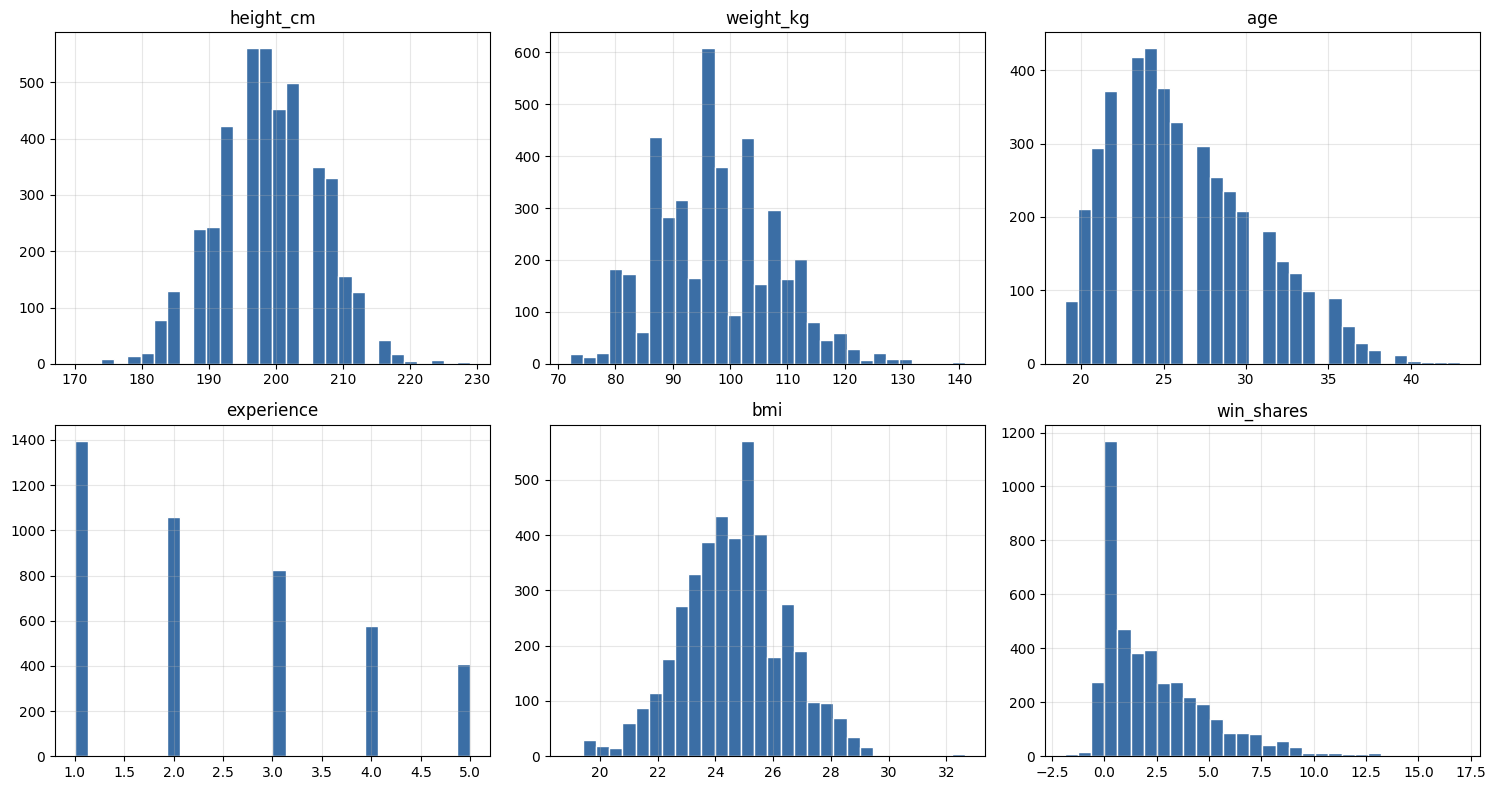

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols = ['height_cm', 'weight_kg', 'age', 'experience', 'bmi', 'win_shares']
for ax, col in zip(axes.flat, cols):
    ax.hist(df[col].dropna(), bins=30, color='#3b6ea5', edgecolor='white')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=110)
plt.show()


### Position breakdown

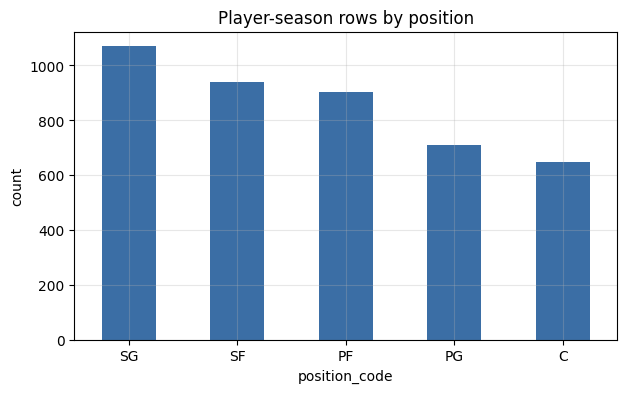

In [6]:
pos_counts = df['position_code'].value_counts()
plt.figure(figsize=(7,4))
pos_counts.plot(kind='bar', color='#3b6ea5')
plt.title('Player-season rows by position')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.savefig('eda_positions.png', dpi=110)
plt.show()

### Correlation heatmap (numeric features)

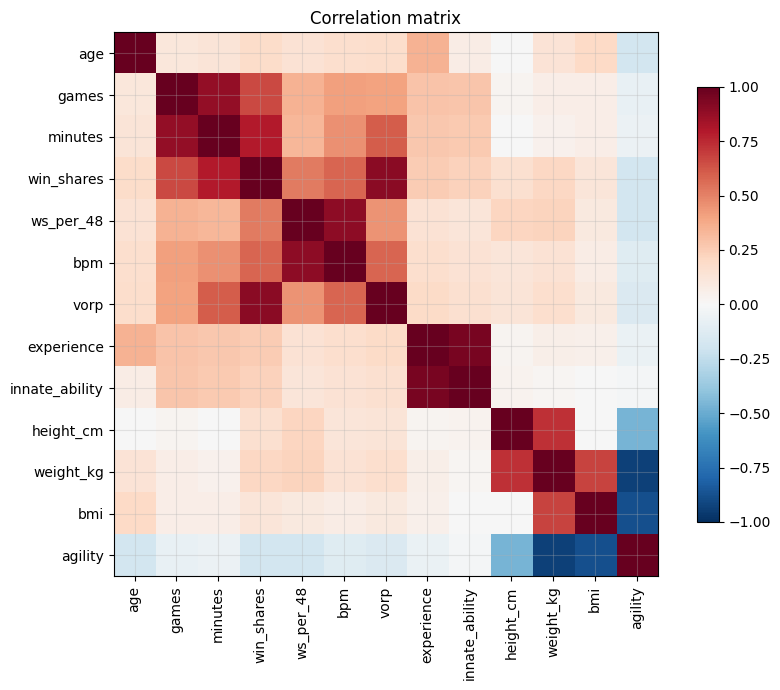

In [7]:
num_cols = ['age','games','minutes','win_shares','ws_per_48','bpm','vorp',
            'experience','innate_ability','height_cm','weight_kg','bmi','agility']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9,7))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=90)
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.title('Correlation matrix')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=110)
plt.show()


### Performance stats by season (are things trending?)

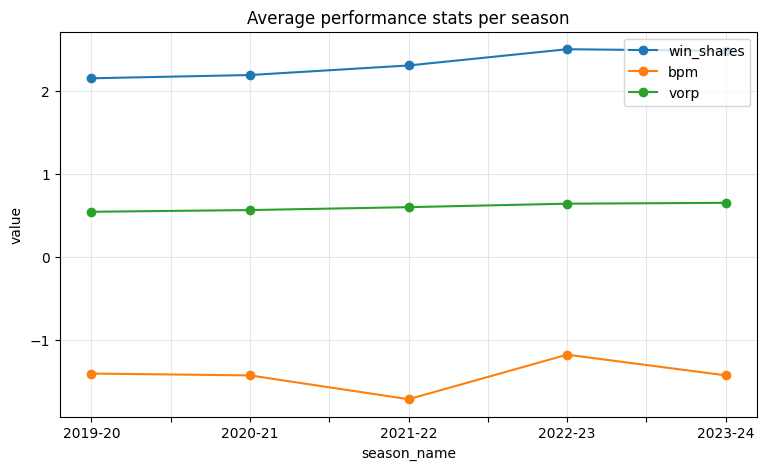

In [8]:
season_avg = df.groupby('season_name')[['win_shares','bpm','vorp']].mean()
season_avg.plot(marker='o')
plt.title('Average performance stats per season')
plt.ylabel('value')
plt.savefig('eda_season_trend.png', dpi=110)
plt.show()

## Part 2 — Project Questions

**Ranking metric used throughout:** `win_shares` is used to define "top N players" per season, since it's a single well-established composite stat available for every row. This is a documented choice, not the only valid one — swap in `vorp` or `bpm` if your team prefers a different metric, and note this assumption in your write-up.

We also exclude `low_sample=True` rows (very low minutes/games) before ranking, so a fluky small-sample stretch doesn't crowd out a genuine top player.

In [9]:
ranking_pool = df[~df['low_sample']].copy()

def top_n_per_season(data, n, metric='win_shares'):
    return (
        data.sort_values(metric, ascending=False)
            .groupby('season_id')
            .head(n)
    )


### Q1 — Height: MJ Trophy (MVP) list vs top-50 players, seasons 2019-20 to 2023-24 (pooled)


MVP-list rows: 120 | Top-50 rows: 250


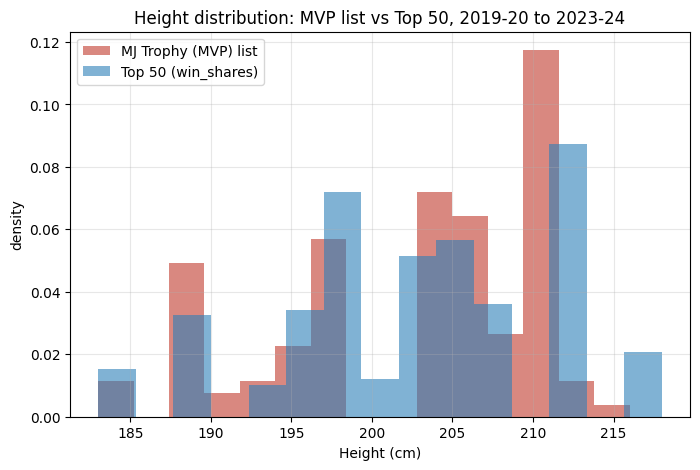

count    120.000000
mean     202.575000
std        8.296666
min      183.000000
25%      198.000000
50%      203.000000
75%      211.000000
max      216.000000
Name: height_cm, dtype: float64

count    250.000000
mean     202.668000
std        8.264562
min      183.000000
25%      198.000000
50%      203.000000
75%      210.250000
max      218.000000
Name: height_cm, dtype: float64


In [11]:
mvp_group = df[df['is_mvp_candidate']]
top50_group = top_n_per_season(ranking_pool, 50)

print('MVP-list rows:', len(mvp_group), '| Top-50 rows:', len(top50_group))

plt.figure(figsize=(8,5))
plt.hist(mvp_group['height_cm'], bins=15, alpha=0.6, label='MJ Trophy (MVP) list', density=True, color='#c0392b')
plt.hist(top50_group['height_cm'], bins=15, alpha=0.6, label='Top 50 (win_shares)', density=True, color='#2c7fb8')
plt.xlabel('Height (cm)'); plt.ylabel('density'); plt.legend()
plt.title('Height distribution: MVP list vs Top 50, 2019-20 to 2023-24')
plt.savefig('q1_height_dist.png', dpi=110)
plt.show()

print(mvp_group['height_cm'].describe())
print()
print(top50_group['height_cm'].describe())

### Q1_Height Distribution (KDE Approach)

/var/folders/hh/y__nk_xn2r5bz4qkvhyp3qpw0000gn/T/ipykernel_26243/1851673623.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(50, 'vorp'))


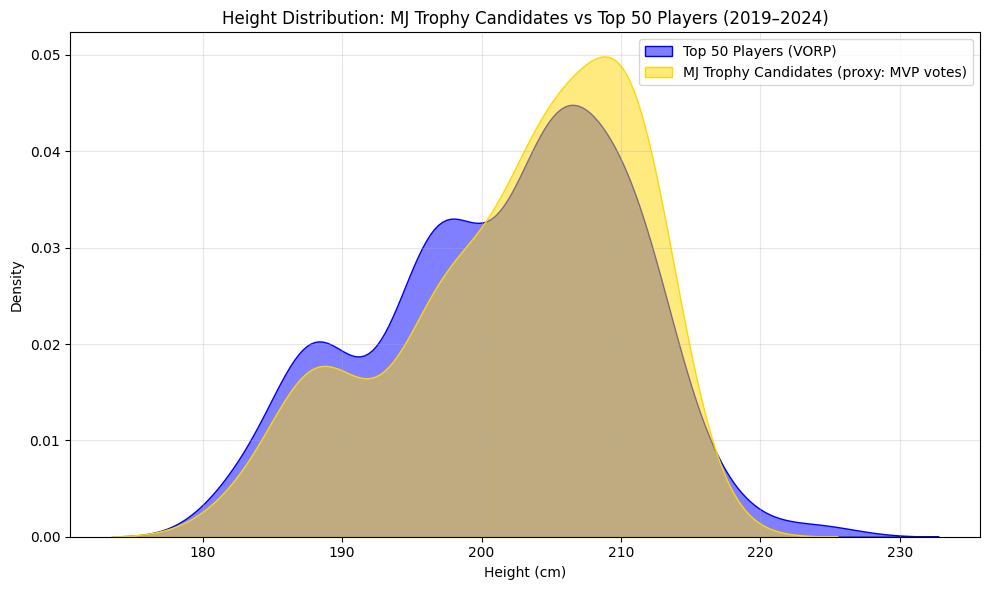

In [25]:
df_valid = df[df['low_sample'] == False].copy()

seasons_all = ['2019-20', '2020-21', '2021-22', '2022-23', '2023-24']
df_valid = df_valid[df_valid['season_name'].isin(seasons_all)]

top_50 = (
    df_valid.groupby('season_name', group_keys=False)
    .apply(lambda x: x.nlargest(50, 'vorp'))
    .reset_index(drop=True)
)
mj_trophy = df_valid[df_valid['is_mvp_candidate'] == True]

plt.figure(figsize=(10, 6))
sns.kdeplot(top_50['height_cm'].dropna(), label='Top 50 Players (VORP)', fill=True, alpha=0.5, color='blue')
sns.kdeplot(mj_trophy['height_cm'].dropna(), label='MJ Trophy Candidates (proxy: MVP votes)', fill=True, alpha=0.5, color='gold')

plt.title('Height Distribution: MJ Trophy Candidates vs Top 50 Players (2019–2024)')
plt.xlabel('Height (cm)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('q1_height_KDE.png', dpi=110)
plt.show()


### Q2 — Experience & height: champion active players vs top-15, last two seasons

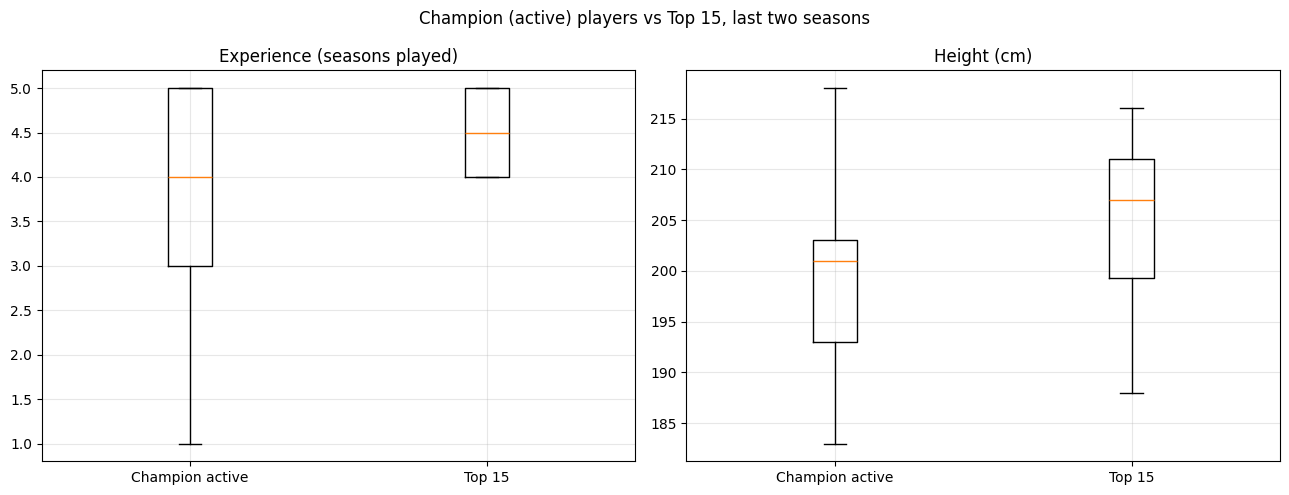

Champion active - experience:
 count    46.000000
mean      3.652174
std       1.385920
min       1.000000
25%       3.000000
50%       4.000000
75%       5.000000
max       5.000000
Name: experience, dtype: float64

Top 15 - experience:
 count    30.000000
mean      4.500000
std       0.508548
min       4.000000
25%       4.000000
50%       4.500000
75%       5.000000
max       5.000000
Name: experience, dtype: float64


In [20]:
last_two = [4, 5]  # 2022-23, 2023-24
champ_active = df[(df['season_id'].isin(last_two)) & (df['is_champion']) & (df['games'] > 0)]
top15 = top_n_per_season(ranking_pool[ranking_pool['season_id'].isin(last_two)], 15)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
for ax, col, title in zip(axes, ['experience','height_cm'], ['Experience (seasons played)','Height (cm)']):
    ax.boxplot([champ_active[col].dropna(), top15[col].dropna()], tick_labels=['Champion active', 'Top 15'])
    ax.set_title(title)
plt.suptitle('Champion (active) players vs Top 15, last two seasons')
plt.tight_layout()
plt.savefig('q2_champ_vs_top15.png', dpi=110)
plt.show()

print('Champion active - experience:\n', champ_active['experience'].describe())
print()
print('Top 15 - experience:\n', top15['experience'].describe())

### Q3 — Point Guard recommendation (based on MJ Trophy / MVP-list appearances, 2019-20 to 2023-24)

In [24]:
active_pgs_2024 = df_valid[
    (df_valid['season_name'] == '2023-24') & 
    (df_valid['position_code'] == 'PG')
]['player_id'].unique()

pg_mvp_history = df_valid[
    (df_valid['is_mvp_candidate'] == True) & 
    (df_valid['player_id'].isin(active_pgs_2024))
]

pg_recommendations = (
    pg_mvp_history.groupby(['player_id', 'full_name'])
    .agg(
        mj_trophy_appearances=('season_id', 'nunique'),   
        avg_mvp_share=('mvp_share', 'mean'),            
        avg_vorp=('vorp', 'mean'),                      
        total_win_shares=('win_shares', 'sum')        
    )
    .reset_index()
    .sort_values(
        ['mj_trophy_appearances', 'avg_mvp_share', 'avg_vorp'], 
        ascending=[False, False, False]
    )
)

print("Top 10 Active Point Guards by MJ Trophy History (2019-2024):")
print(pg_recommendations.head(10).to_string(index=False))

print("\nFinal Top 3 Recommendations:")
print(pg_recommendations.head(3).to_string(index=False))


Top 10 Active Point Guards by MJ Trophy History (2019-2024):
player_id               full_name  mj_trophy_appearances  avg_mvp_share  avg_vorp  total_win_shares
antetgi01   Giannis Antetokounmpo                      5       0.538400  6.440000             224.0
doncilu01             Luka Dončić                      5       0.193600  6.200000              92.6
jamesle01            LeBron James                      3       0.249333  5.000000             114.5
curryst01           Stephen Curry                      3       0.152667  4.966667              24.8
 paulch01              Chris Paul                      3       0.055333  3.700000              27.5
gilgesh01 Shai Gilgeous-Alexander                      2       0.346000  6.350000              52.0
hardeja01            James Harden                      2       0.182000  5.500000              40.2
brunsja01           Jalen Brunson                      2       0.072000  4.450000              39.8
lillada01          Damian Lillard      

### Hypothesis 1 — Agility (height/weight) of top-20 players: has it increased?

Recent group: 2022-23 & 2023-24 (season_id 4,5). Older group: 2020-21 & 2021-22 (season_id 2,3).
We check normality first (Shapiro-Wilk) to decide between an independent t-test and the non-parametric Mann-Whitney U test.

In [27]:
top20 = top_n_per_season(ranking_pool, 20)

recent_agility = top20[top20['season_id'].isin([4,5])]['agility'].dropna()
older_agility  = top20[top20['season_id'].isin([2,3])]['agility'].dropna()

print('Recent (22-23,23-24) n=', len(recent_agility), 'mean=', recent_agility.mean())
print('Older  (20-21,21-22) n=', len(older_agility),  'mean=', older_agility.mean())

# normality check
print('Shapiro recent:', stats.shapiro(recent_agility))
print('Shapiro older :', stats.shapiro(older_agility))

Recent (22-23,23-24) n= 40 mean= 1.9704863207646461
Older  (20-21,21-22) n= 40 mean= 1.9401830222250112
Shapiro recent: ShapiroResult(statistic=np.float64(0.9203438240435802), pvalue=np.float64(0.007895326128440443))
Shapiro older : ShapiroResult(statistic=np.float64(0.9184213712455251), pvalue=np.float64(0.006871632971906792))


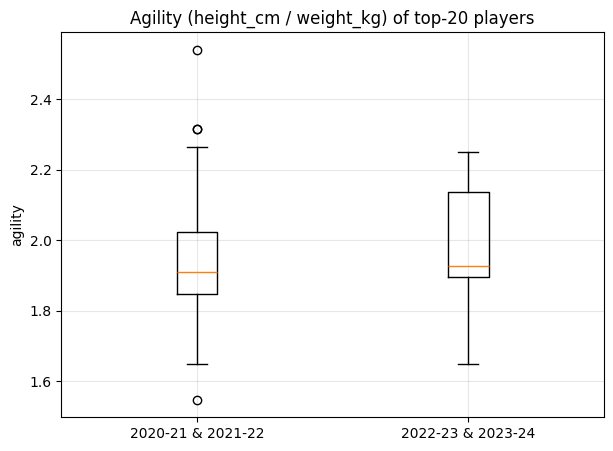

In [28]:
fig, ax = plt.subplots(figsize=(7,5))
ax.boxplot([older_agility, recent_agility], tick_labels=['2020-21 & 2021-22', '2022-23 & 2023-24'])
ax.set_title('Agility (height_cm / weight_kg) of top-20 players')
ax.set_ylabel('agility')
plt.savefig('h1_agility_boxplot.png', dpi=110)
plt.show()

In [30]:
# Choose test based on normality result above.
# If BOTH groups look normal (p > 0.05 on Shapiro) -> Welch's t-test (unequal variance assumed by default, robust choice)
# If either group fails normality -> Mann-Whitney U (non-parametric)

shapiro_recent_p = stats.shapiro(recent_agility).pvalue
shapiro_older_p  = stats.shapiro(older_agility).pvalue

if shapiro_recent_p > 0.05 and shapiro_older_p > 0.05:
    stat, p = stats.ttest_ind(recent_agility, older_agility, equal_var=False)
    test_used = "Welch's t-test"
else:
    stat, p = stats.mannwhitneyu(recent_agility, older_agility, alternative='two-sided')
    test_used = 'Mann-Whitney U'

print(f'Test used: {test_used}')
print(f'statistic={stat:.4f}, p-value={p:.4f}')

pooled_std = np.sqrt(((len(recent_agility)-1)*recent_agility.std()**2 +
                       (len(older_agility)-1)*older_agility.std()**2) /
                      (len(recent_agility)+len(older_agility)-2))
cohens_d = (recent_agility.mean() - older_agility.mean()) / pooled_std
print(f"Cohen's d: {cohens_d:.3f}")

alpha = 0.05
if p < alpha:
    direction = 'increased' if recent_agility.mean() > older_agility.mean() else 'decreased'
    print(f'Result: statistically significant difference (p<{alpha}) -- agility appears to have {direction}.')
else:
    print(f'Result: not statistically significant at alpha={alpha} -- no reliable evidence of a change in agility.')

Test used: Mann-Whitney U
statistic=957.0000, p-value=0.1309
Cohen's d: 0.168
Result: not statistically significant at alpha=0.05 -- no reliable evidence of a change in agility.


### Hypothesis 2 — Innate ability (experience/age) of champion active players: has it increased?


In [36]:
past_seasons = ['2020-21', '2021-22']
new_seasons  = ['2022-23', '2023-24']

df_unique = df_valid.drop_duplicates(subset=['player_id', 'season_id'])

champ_past = df_unique[
    (df_unique['season_name'].isin(past_seasons)) &
    (df_unique['is_champion'] == True)
]
champ_new = df_unique[
    (df_unique['season_name'].isin(new_seasons)) &
    (df_unique['is_champion'] == True)
]

innate_past = champ_past['innate_ability'].dropna()
innate_new  = champ_new['innate_ability'].dropna()

In [37]:
_, p_norm_ip = stats.shapiro(innate_past)
_, p_norm_in = stats.shapiro(innate_new)
print(f"Shapiro-Wilk innate_ability — past: p={p_norm_ip:.4f} | new: p={p_norm_in:.4f}")

both_normal_i = (p_norm_ip > alpha) and (p_norm_in > alpha)

if both_normal_i:
    print("Both groups normal -> Welch's t-test")
    t_stat_i, p_val_i = stats.ttest_ind(innate_new, innate_past, equal_var=False, alternative='greater')
    test_name_i = "Welch's t-test"
else:
    print("At least one group non-normal -> Mann-Whitney U test")
    t_stat_i, p_val_i = stats.mannwhitneyu(innate_new, innate_past, alternative='greater')
    test_name_i = "Mann-Whitney U"

print(f"\n[{test_name_i}] Mean past: {innate_past.mean():.4f} | Mean new: {innate_new.mean():.4f}")
print(f"Statistic: {t_stat_i:.4f} | P-value: {p_val_i:.4f}")

if p_val_i < alpha:
    print("Result: H0 rejected. Expert claim is statistically supported.")
else:
    print("Result: H0 not rejected.")

print(f"\nMean age (past champions): {champ_past['age'].mean():.2f}")
print(f"Mean age (new champions):  {champ_new['age'].mean():.2f}")

Shapiro-Wilk innate_ability — past: p=0.9836 | new: p=0.1720
Both groups normal -> Welch's t-test

[Welch's t-test] Mean past: 0.0842 | Mean new: 0.1480
Statistic: 7.2960 | P-value: 0.0000
Result: H0 rejected. Expert claim is statistically supported.

Mean age (past champions): 27.52
Mean age (new champions):  27.67


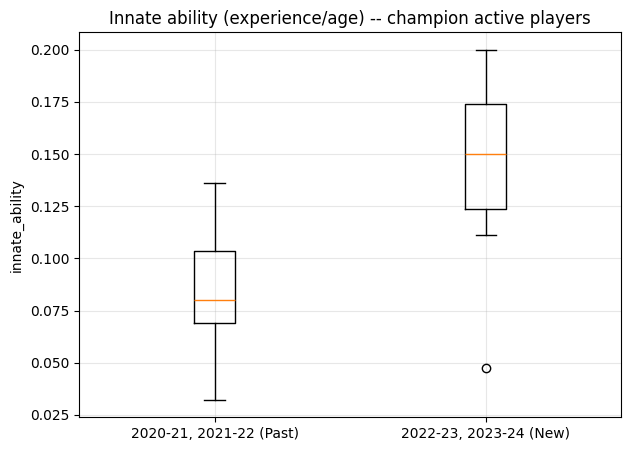

In [32]:
fig, ax = plt.subplots(figsize=(7,5))
ax.boxplot([innate_past, innate_new],
           tick_labels=['2020-21, 2021-22 (Past)', '2022-23, 2023-24 (New)'])
ax.set_title('Innate ability (experience/age) -- champion active players')
ax.set_ylabel('innate_ability')
plt.savefig('h2_innate_ability_boxplot.png', dpi=110)
plt.show()
